# Week 6 Phase 3.5 — Regime-target design

This notebook asks whether the Phase 1–3 late-window median depth target is
also a good target for persistent conduction-like versus keyhole-like
behaviour. It does **not** replace T0 silently, fit a GP classifier, or begin
active learning.

```text
Phase 3.5
├── A. Provenance, label and time-alignment audit
├── B. Scan-position and geometry evolution
├── C. Representative simulation case studies
├── D. Candidate regime-target construction
├── E. Candidate-versus-label evaluation
├── F. Robustness and sensitivity checks
└── G. Final target recommendation
```

## Terms used in this notebook

- **Instantaneous melt-pool extent:** the coordinate span at one monitor row,
  not the cumulative melted-track length.
- **Penetration depth:** `max(0, -z_min)`, measured below the original surface.
- **Aspect ratio:** penetration depth divided by transverse width. Both are
  lengths, so the ratio is dimensionless.
- **Normalized scan position:** physical laser position mapped to `s=0` at the
  positive-X start and `s=1` at domain exit.
- **Right-censoring:** a simulation stops being observed before a later event
  could be seen. For example, a run ending at `s=0.7` cannot tell us what would
  happen at `s=0.9`.
- **Transient:** a short-lived excursion. A one-frame peak is a transient
  candidate, not automatically persistent behaviour.
- **Quasi-steady state:** a period whose geometry changes relatively slowly,
  without claiming perfect equilibrium.
- **Rolling window:** a moving physical-distance interval.
- **Rolling median:** the median inside that interval. For `[0.3, 0.4, 3.0]`,
  the median is `0.4`, so the isolated `3.0` spike is suppressed.
- **Persistence:** geometry that remains elevated over a declared physical
  distance, here tested at 20, 50, and 100 µm.
- **Quantile:** a distribution cutoff. **q95** is the value exceeded by only
  5% of observations.
- **Spike:** an isolated or very brief extreme value.
- **Cluster bootstrap:** resampling complete simulations so correlated frames
  from one simulation stay together.
- **ROC AUC:** the probability that a random positive receives a higher score
  than a random negative.
- **Precision–recall AUC:** ranking quality focused on the positive class.
- **Prevalence baseline:** the positive fraction; random PR performance is
  approximately this value.
- **Balanced accuracy:** the mean of sensitivity and specificity.
- **Sensitivity / recall:** fraction of positives correctly detected.
- **Specificity:** fraction of negatives correctly rejected.
- **Precision:** fraction of predicted positives that are positive.
- **F1:** harmonic mean of precision and recall.
- **Nested leave-one-out:** one simulation is held out while any threshold is
  selected only from the other simulations.
- **Circular validation:** evaluating a depth-derived proxy against labels
  initially seeded using depth.
- **Regime proxy:** a continuous geometric summary intended to reflect, but
  not define as ground truth, the physical regime.
- **Continuous level-set target:** a scalar whose threshold could later define
  a boundary; no such boundary is estimated here.

Branch: codex/week6-phase3-5-regime-target-design
HEAD: b112f6b22898976f77410190614cb4fb218d38f9
Pinned revision: 0e859b748fdbc8454f66e58e101e333ac0479d42


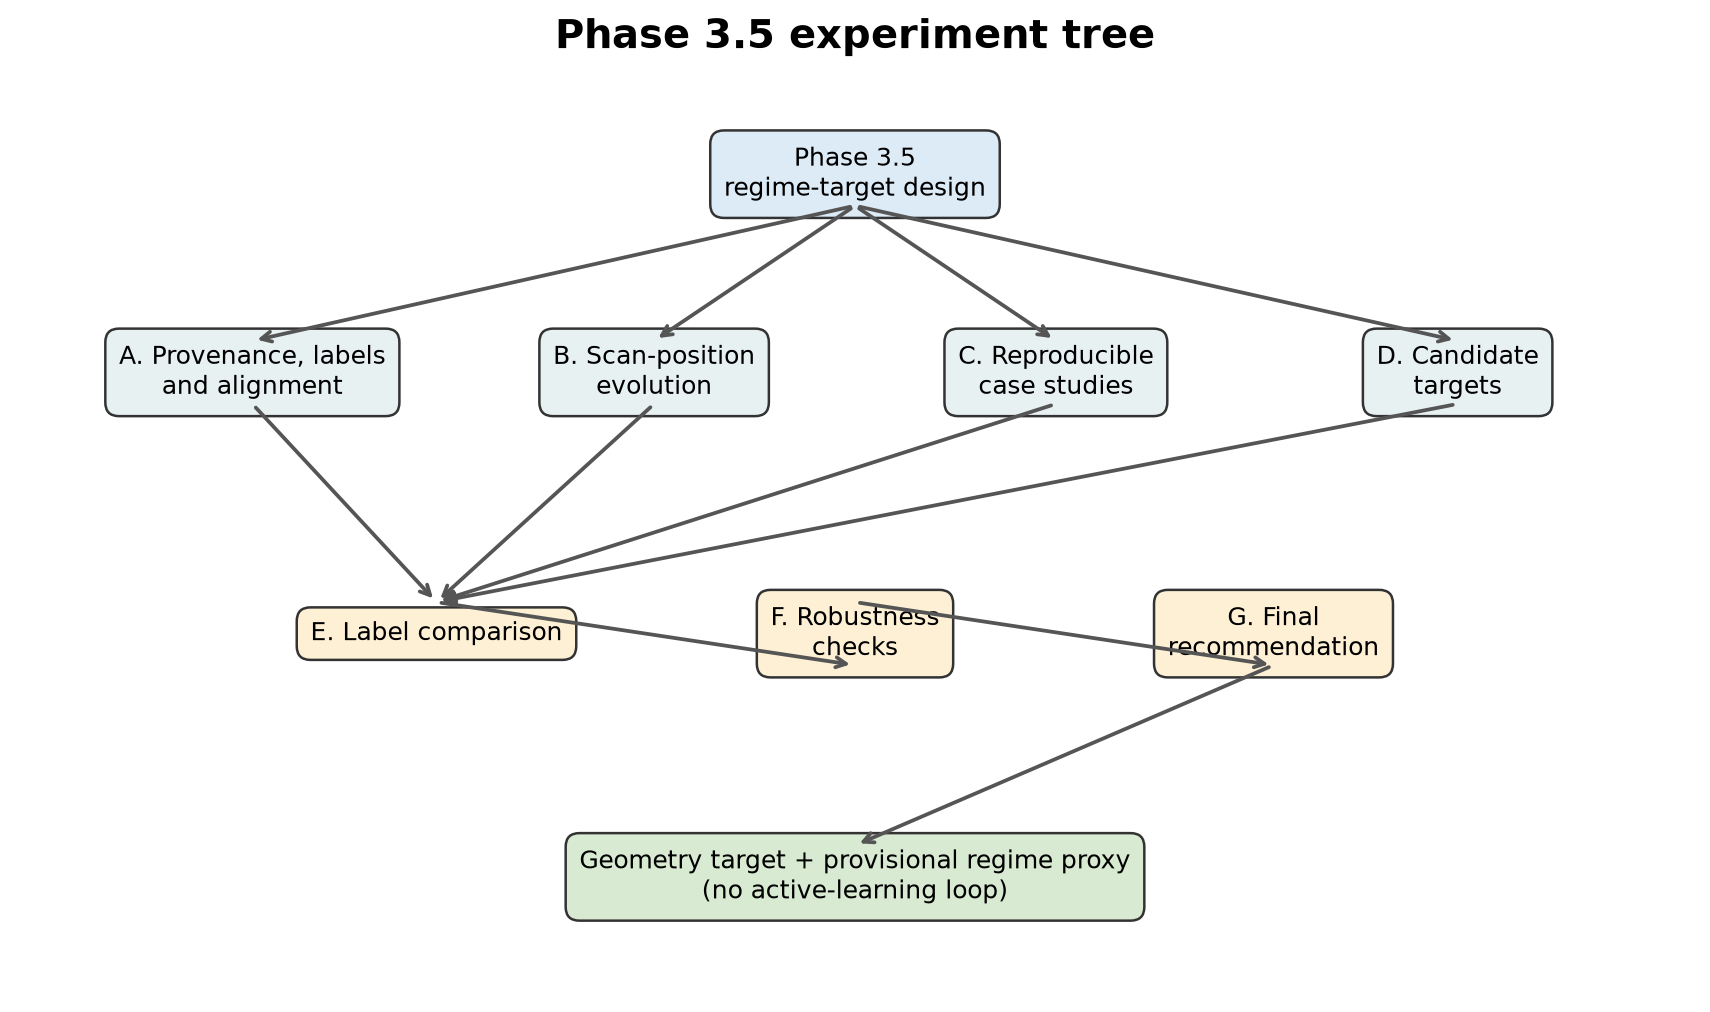

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
OUT = ROOT / "outputs" / "week6_03_5_regime_target_design"
configuration = json.loads((OUT / "phase3_5_configuration.json").read_text(encoding="utf-8"))
summary = json.loads((OUT / "summary.json").read_text(encoding="utf-8"))
print("Branch:", configuration["branch"])
print("HEAD:", configuration["head"])
print("Pinned revision:", configuration["huggingface"]["revision"])
display(Image(filename=str(OUT / "figures" / "01_phase3_5_experiment_tree.png")))

The experiment tree fixes the order of evidence. Provenance and alignment are
checked before candidate scores are interpreted. This cell does not establish
which target is best; it only verifies the analysis boundary and inputs.

## A. Provenance, label and time-alignment audit

Physical labels are kept separate from technical/annotation states.
`Screenshot Bug` is never used as a physical Keyhole-negative class.

,stored_label,normalized_label,label_type,included_in_regime_analysis,exclusion_or_usage_note,provenance
0,Conduction,Conduction,physical,True,NaN,final-labels_all.csv and per-simulation frames...
1,Keyhole,Keyhole,physical,True,NaN,final-labels_all.csv and per-simulation frames...
2,Forming Phase,Forming Phase,physical_transition,True,Excluded from binary Conduction-versus-Keyhole...,final-labels_all.csv and per-simulation frames...
3,Initial Emptiness,Initial Emptiness,technical_or_annotation,False,No melt-regime claim; excluded from regime met...,final-labels_all.csv and per-simulation frames...
4,Screenshot Bug,Screenshot Bug,technical_or_annotation,False,Never used as a Keyhole-negative physical class.,final-labels_all.csv and per-simulation frames...


,record_type,label,label_type,frame_count,frame_fraction,simulation_count,value,note
0,label,Initial Emptiness,technical_or_annotation,3275.0,0.050021,116.0,NaN,NaN
1,label,Forming Phase,physical_transition,10326.0,0.157716,177.0,NaN,NaN
2,label,Conduction,physical,43881.0,0.670225,238.0,NaN,NaN
3,label,Screenshot Bug,technical_or_annotation,7469.0,0.114079,150.0,NaN,NaN
4,label,Keyhole,physical,521.0,0.007958,9.0,NaN,NaN
5,population_summary,total_label_rows,NaN,NaN,NaN,NaN,65472.0,NaN
6,population_summary,unique_simulations,NaN,NaN,NaN,NaN,241.0,NaN
7,population_summary,any_keyhole_simulations,NaN,NaN,NaN,NaN,9.0,NaN
8,population_summary,both_conduction_and_keyhole_simulations,NaN,NaN,NaN,NaN,8.0,NaN
9,population_summary,conduction_only_simulations,NaN,NaN,NaN,NaN,230.0,NaN


Exact aligned frames: 65472
Ambiguous frames: 0


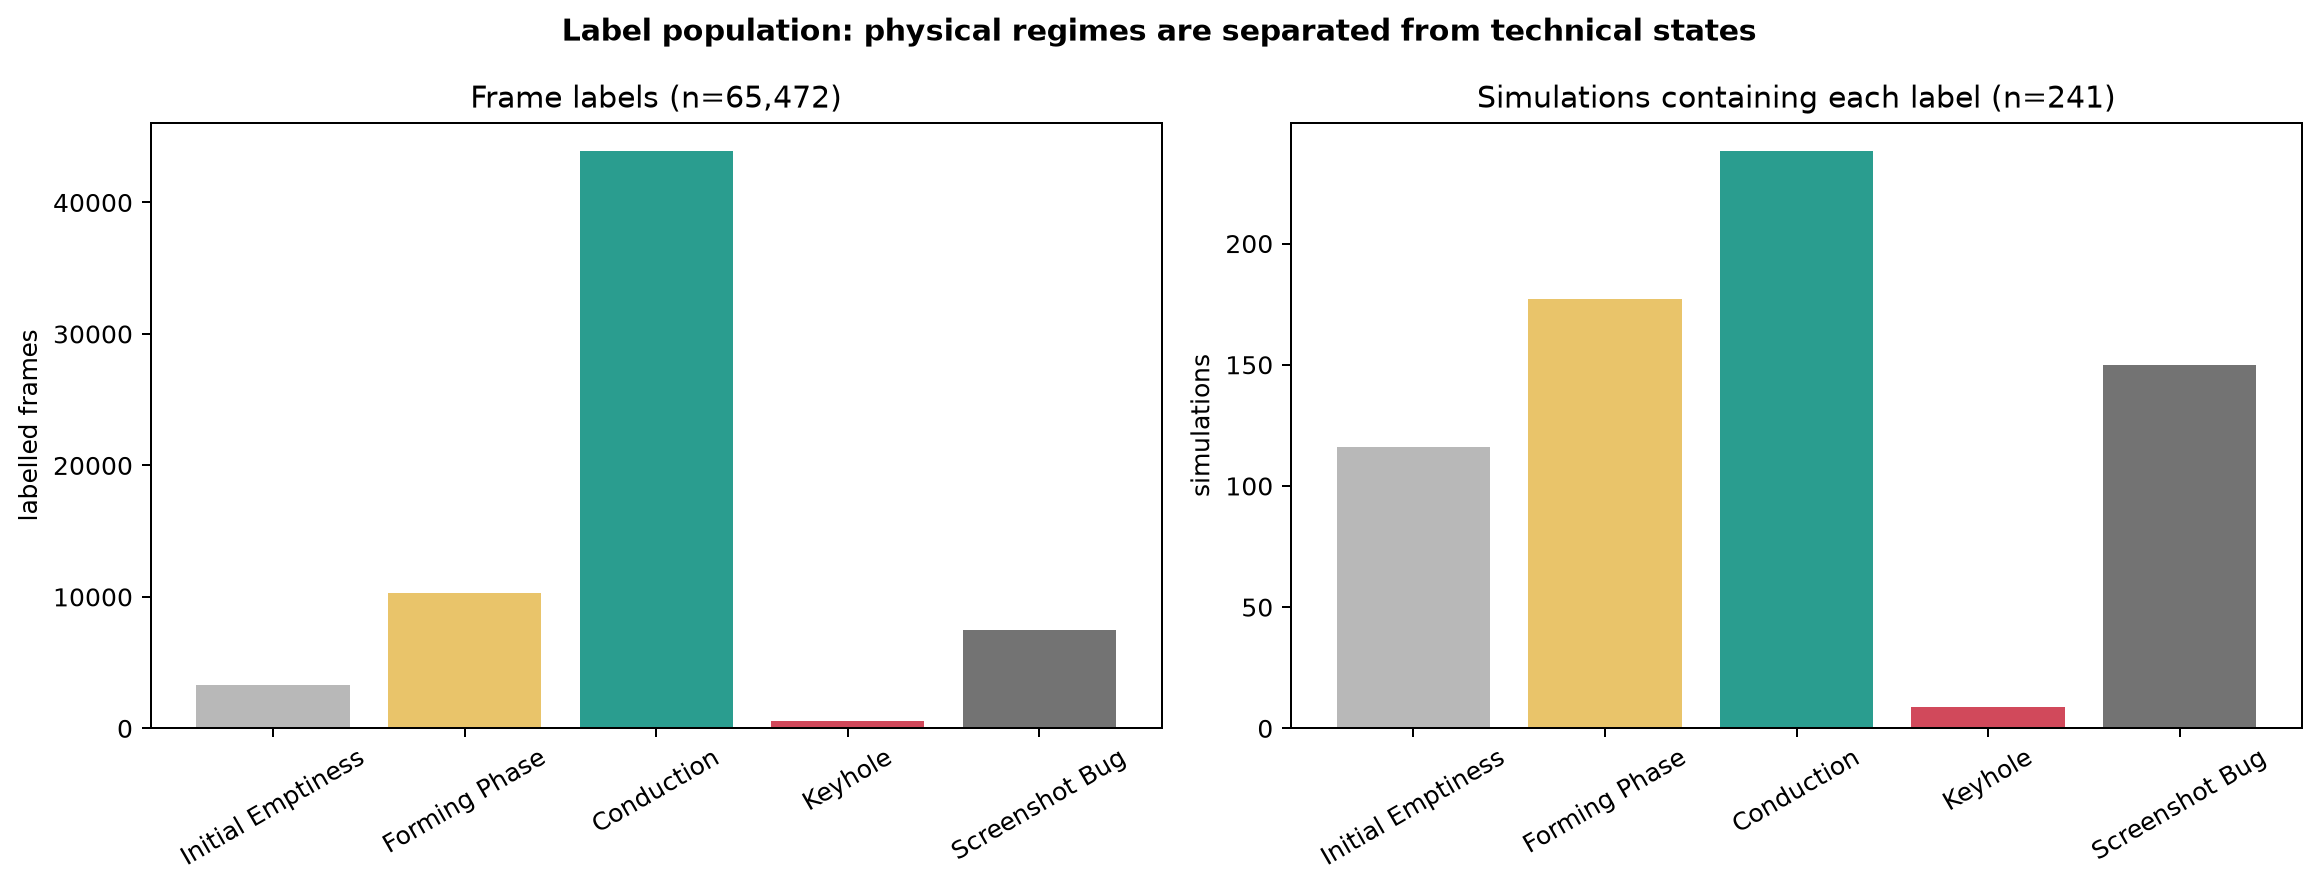

In [2]:
label_dictionary = pd.read_csv(OUT / "label_dictionary.csv")
label_population = pd.read_csv(OUT / "label_population_audit.csv")
alignment = pd.read_csv(OUT / "label_monitor_alignment_audit.csv")
display(label_dictionary)
display(label_population)
print("Exact aligned frames:", int(alignment["exact_alignment_count"].sum()))
print("Ambiguous frames:", int(alignment["ambiguous_alignment_count"].sum()))
display(Image(filename=str(OUT / "figures" / "03_label_count_overview.png")))

All labelled frames align exactly by stored timestep to `iter.dat`; alignment
uncertainty is therefore zero for this pinned revision. The important
limitation is different: only nine simulations contain Keyhole, and every
provenance record retains a depth-based automatic seed. Agreement with depth
is descriptive and potentially circular, even when frames were human-verified.

## B. Scan-position and geometry evolution

Raw monitor time is converted into physical laser X, then into normalized
position using fixed domain bounds. Each simulation keeps its real stopping
position; it is never stretched to make its final row look like `s=1`.

,last_active_melt_position_s,global_max_depth_position_s,persistent_max_depth_position_s,global_max_ratio_position_s,persistent_max_ratio_position_s
count,241.000000,241.000000,240.000000,241.000000,240.000000
mean,0.937390,0.531678,0.540287,0.536216,0.512293
std,0.367591,0.184819,0.157385,0.251281,0.207252
min,0.160227,0.123089,0.118972,0.055403,0.078139
25%,0.619819,0.397445,0.430093,0.356564,0.358415
50%,0.962034,0.510826,0.533976,0.506296,0.505014
75%,1.248553,0.647709,0.663530,0.676301,0.634657
max,1.580452,1.037040,0.880830,1.118908,0.958740


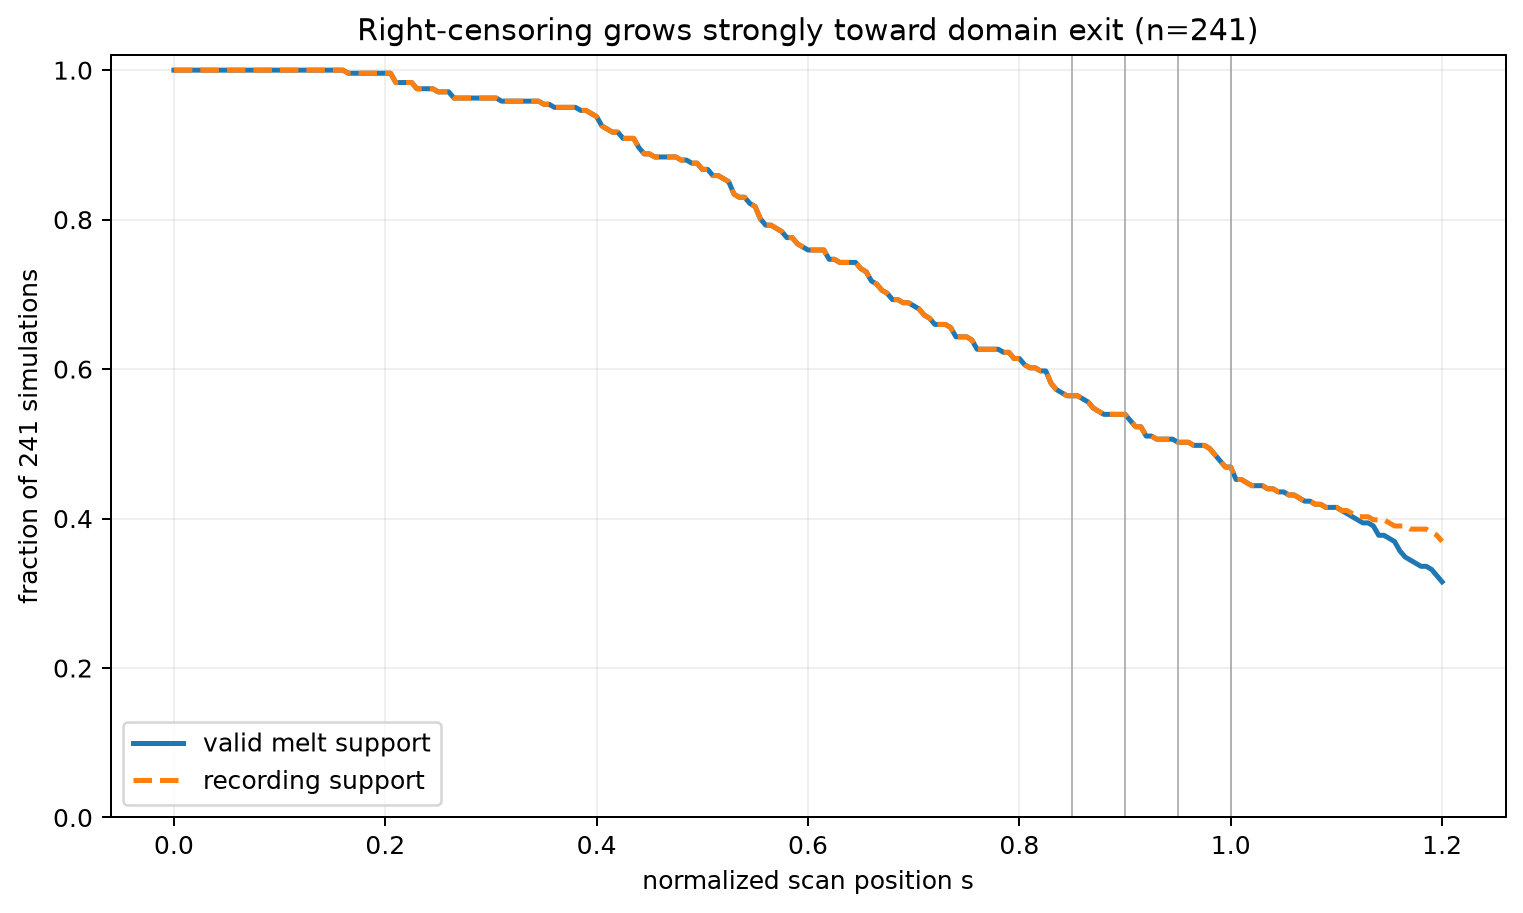

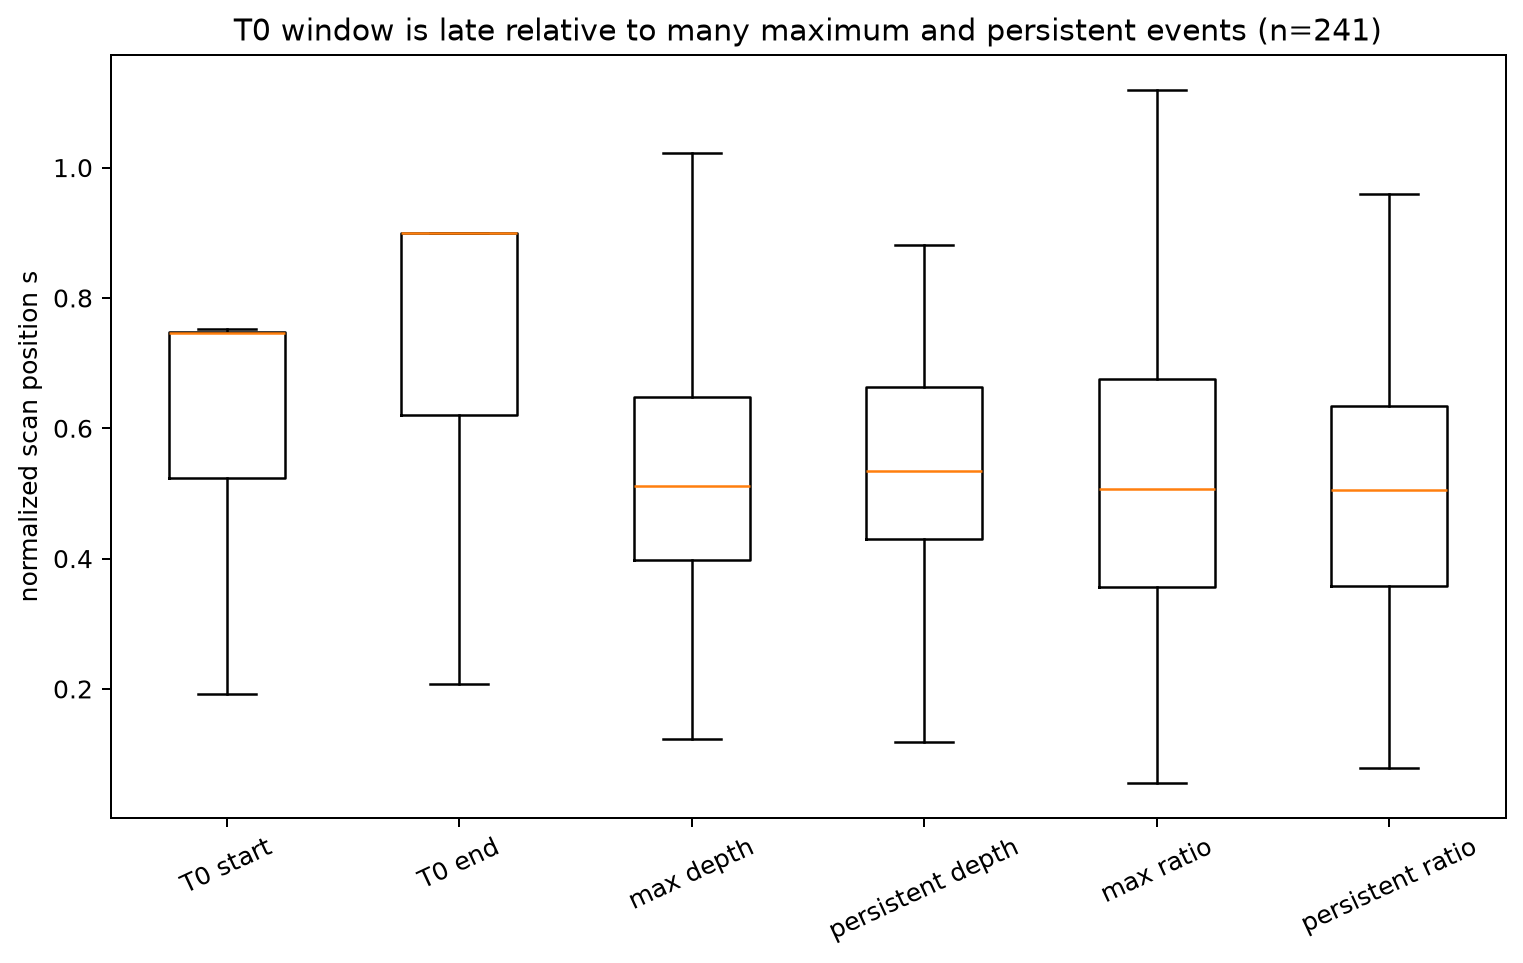

In [3]:
coverage = pd.read_csv(OUT / "scan_coverage_summary.csv")
active = pd.read_csv(OUT / "simulation_active_interval_summary.csv")
display(active[[
    "last_active_melt_position_s", "global_max_depth_position_s",
    "persistent_max_depth_position_s", "global_max_ratio_position_s",
    "persistent_max_ratio_position_s"
]].describe())
display(Image(filename=str(OUT / "figures" / "04_scan_coverage_curve.png")))
display(Image(filename=str(OUT / "figures" / "14_T0_window_vs_maximum_and_persistent_event_locations.png")))

The support curve shows substantial right-censoring near domain exit. The
event-location comparison also shows why T0 and a regime target answer
different questions: many strongest or persistent events occur before T0's
late window. This does not make T0 wrong; it makes it a geometry summary.

## C. Representative simulation case studies

Examples are selected only after the population audit using explicit rules:
closest to a group median, strongest reproducible transition support, or a
declared maximum-versus-persistence disagreement score.

,case_id,case_name,simulation_id,selection_rule,selection_evidence,any_keyhole,keyhole_fraction,G1_max_depth_um,G3_persistent_depth_um,R1_max_aspect_ratio,R3_persistent_aspect_ratio,phase1_unstable
0,C1,Typical conduction-only,sim_00157,No Keyhole label; R3 closest to the conduction...,"R3=0.3428, group median=0.3428.",False,0.000000,31.42675,30.913105,0.351519,0.342817,False
1,C2,Typical keyhole-containing,sim_00137,Keyhole-containing; closest joint robust dista...,"R3=0.8101, keyhole fraction=0.2402.",True,0.240196,151.47990,140.531400,0.865642,0.810148,False
2,C3,Mixed Conduction-to-Keyhole transition,sim_00222,"Both labels, exact alignment, and maximum bala...",Balanced transition support=92 frames.,True,0.059633,155.83500,149.850050,1.030471,0.990791,True
3,C4,Maximum-versus-persistence disagreement,sim_00036,Largest combined percentile rank of global R1 ...,"R1=1.0135, R3=0.4323, gap=0.5813.",True,0.066667,182.72740,78.009640,1.013547,0.432278,True
4,C5,Persistent deep-melt,sim_00214,Largest combined rank of high R3 and small rel...,"R3=0.4925, relative gap=0.0036.",False,0.000000,86.74041,86.561020,0.494259,0.492500,False
5,C6,Phase 1 unstable-window,sim_00038,Independent Phase 1 unstable ID; R3 closest to...,"R3=0.4486, unstable median=0.4486.",True,0.175439,160.27100,78.441860,0.918098,0.448646,True


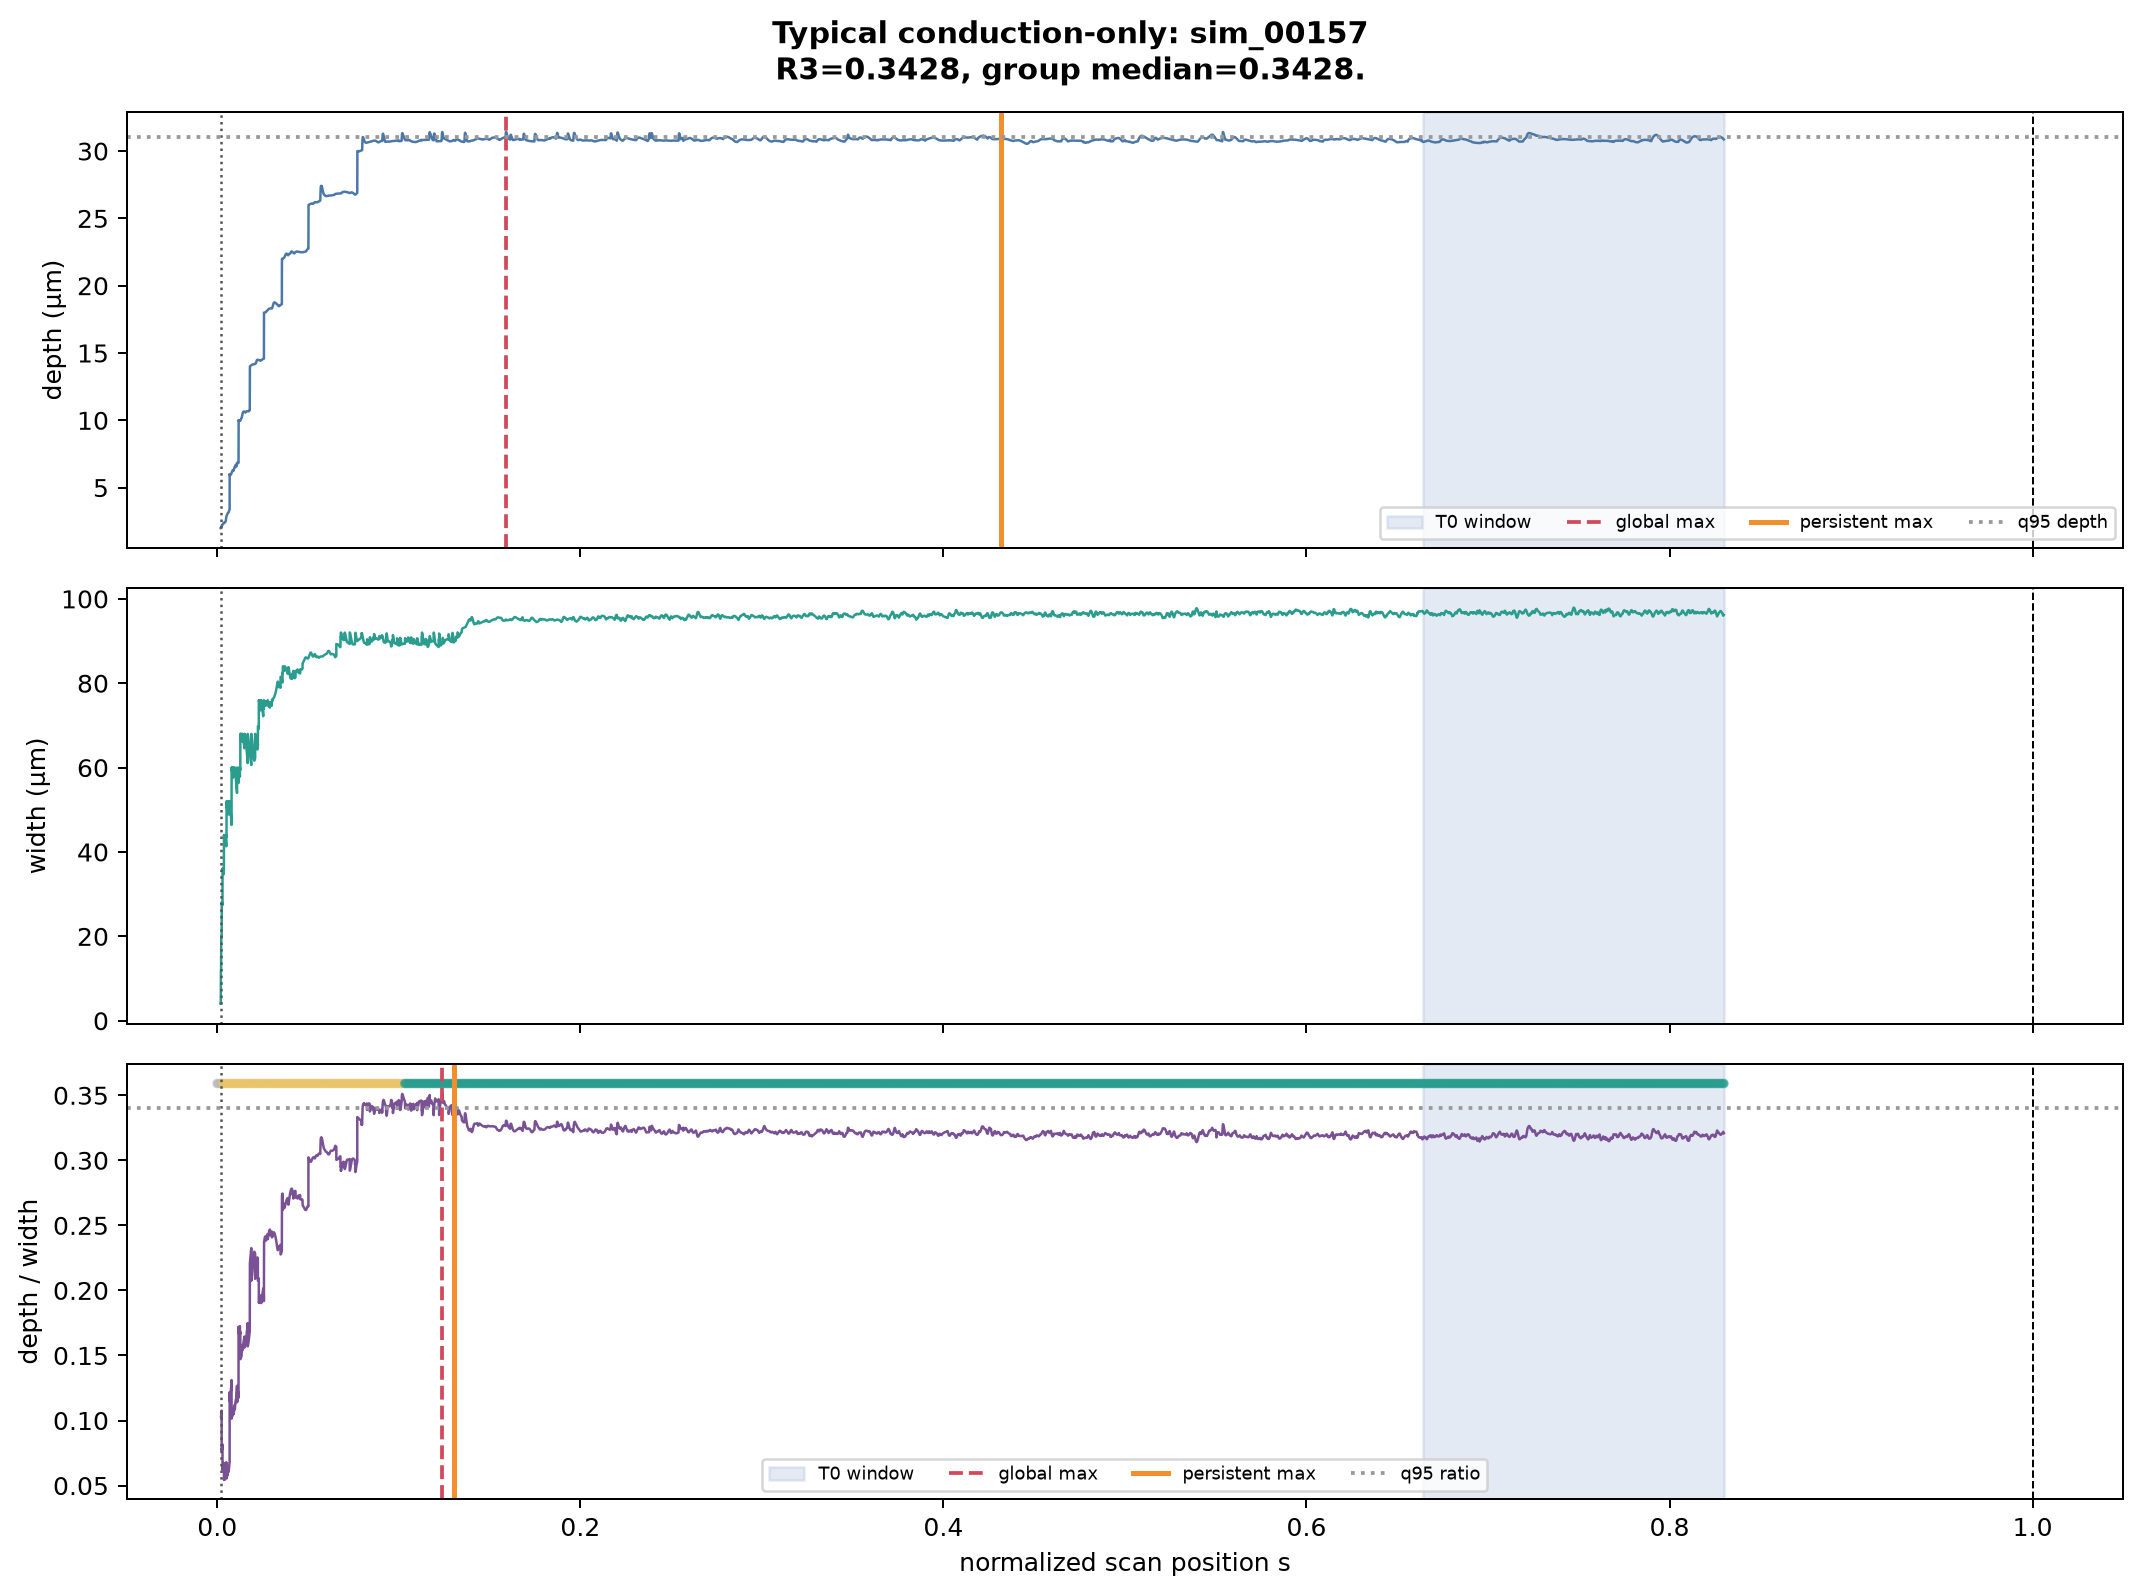

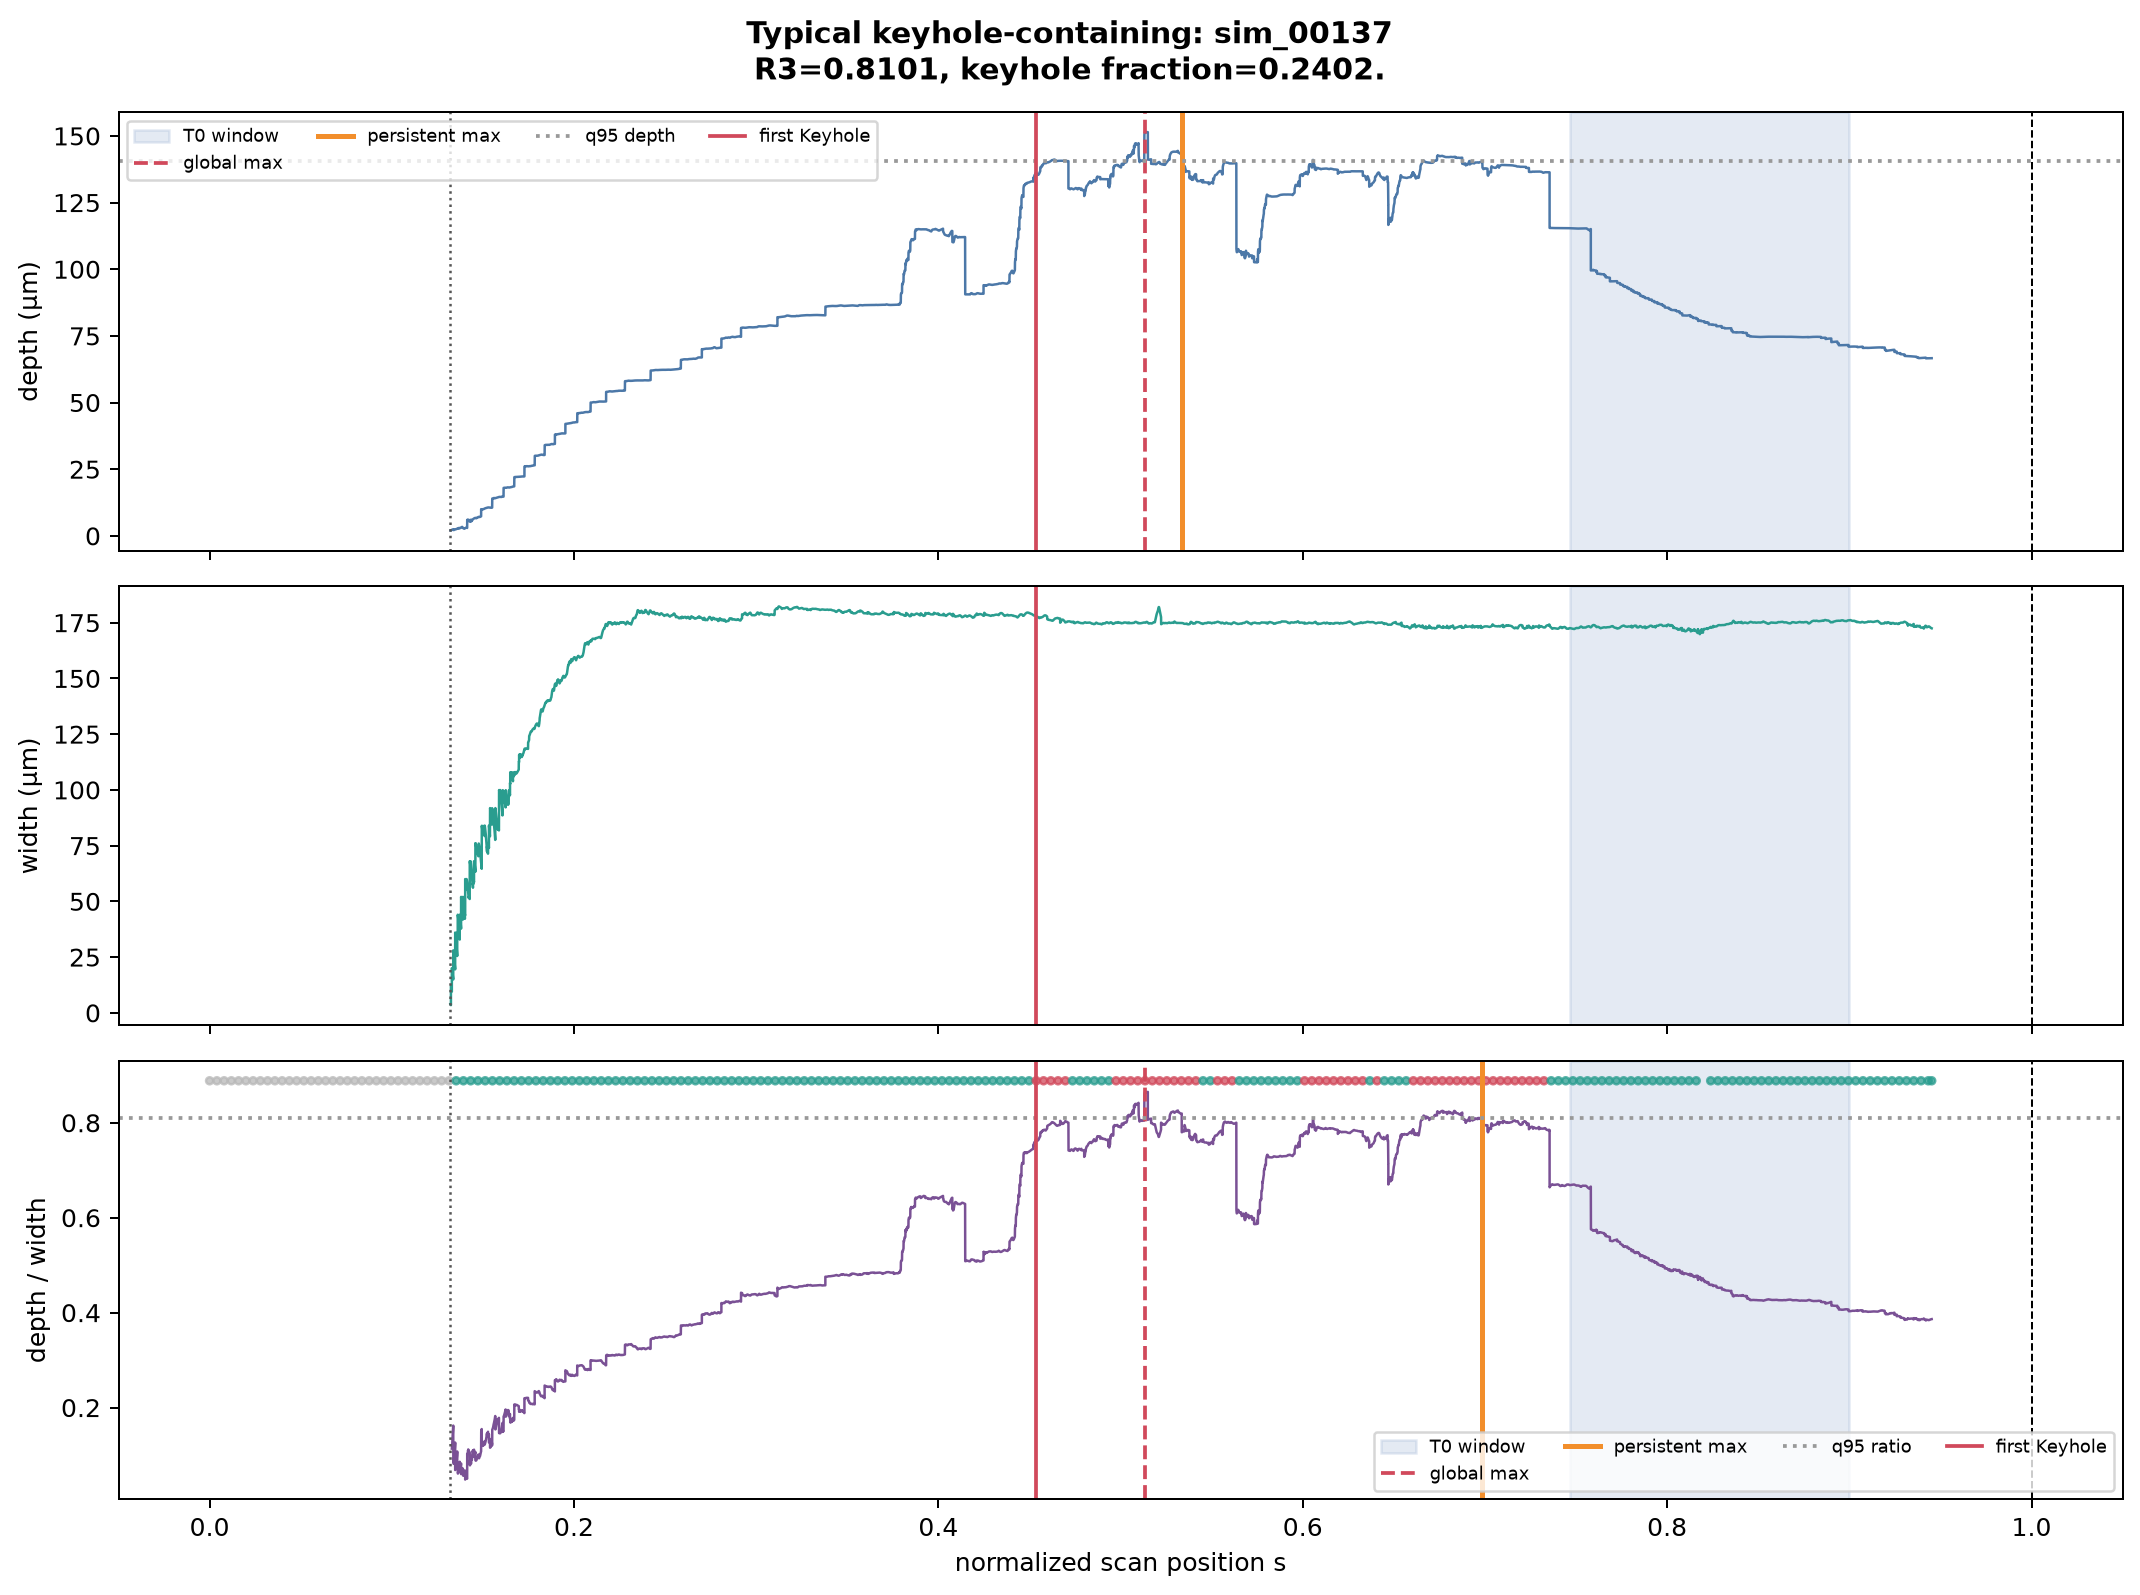

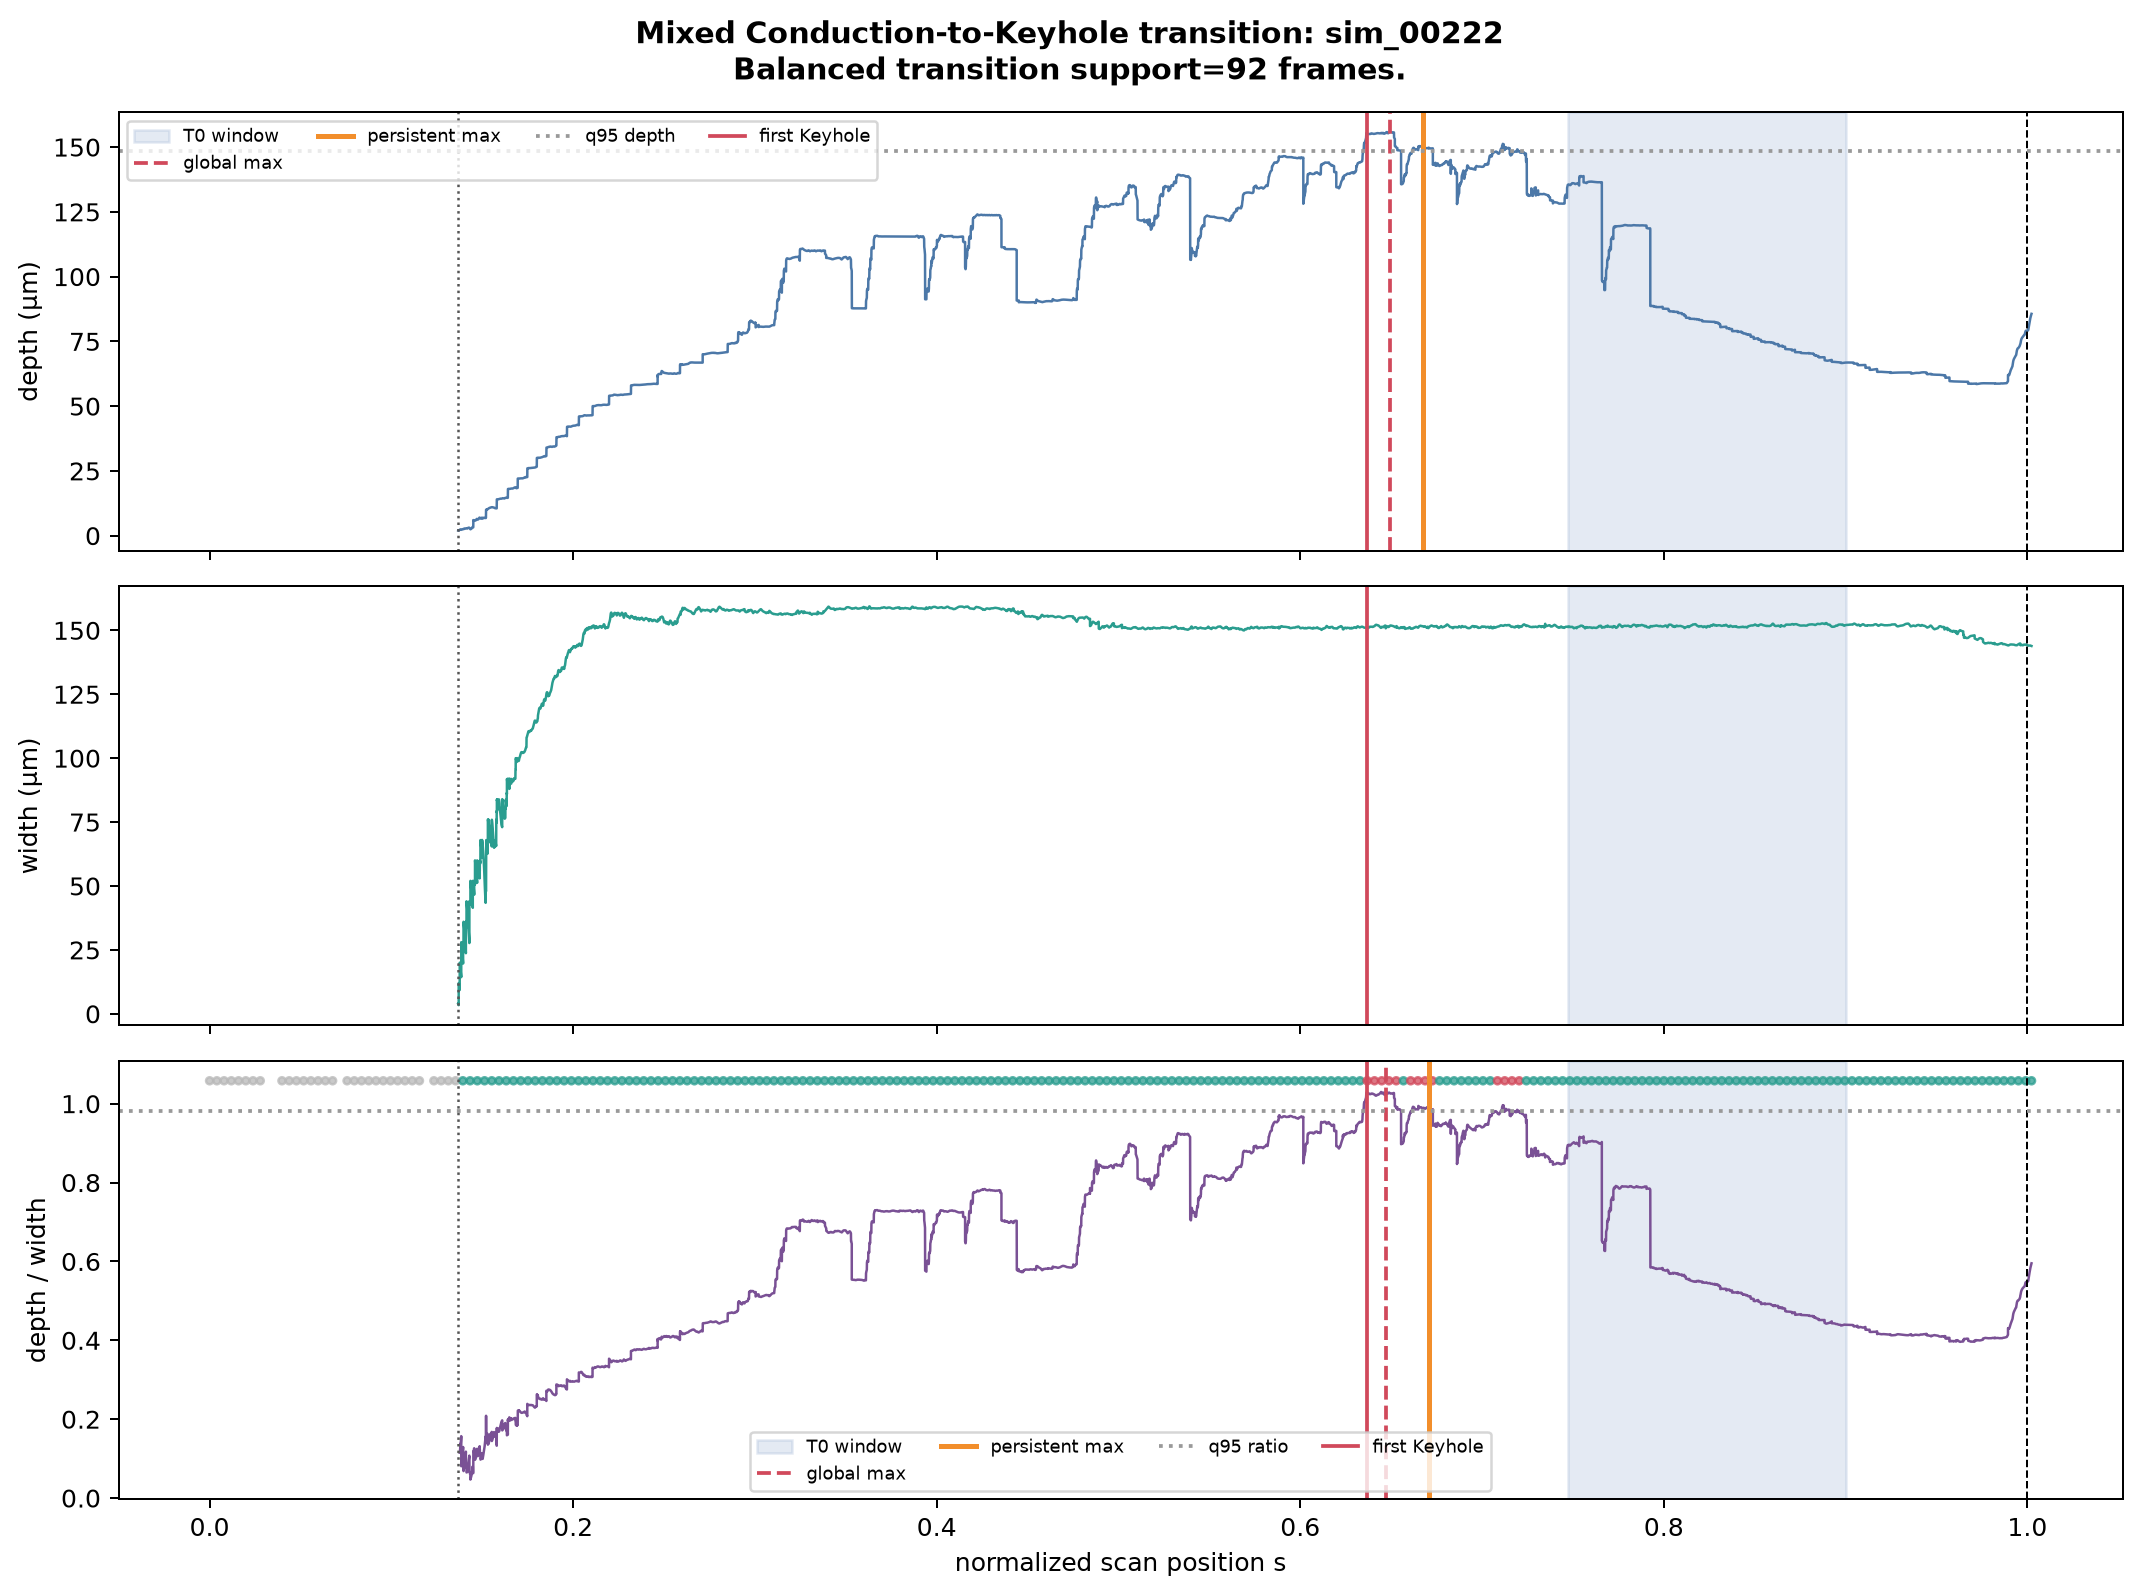

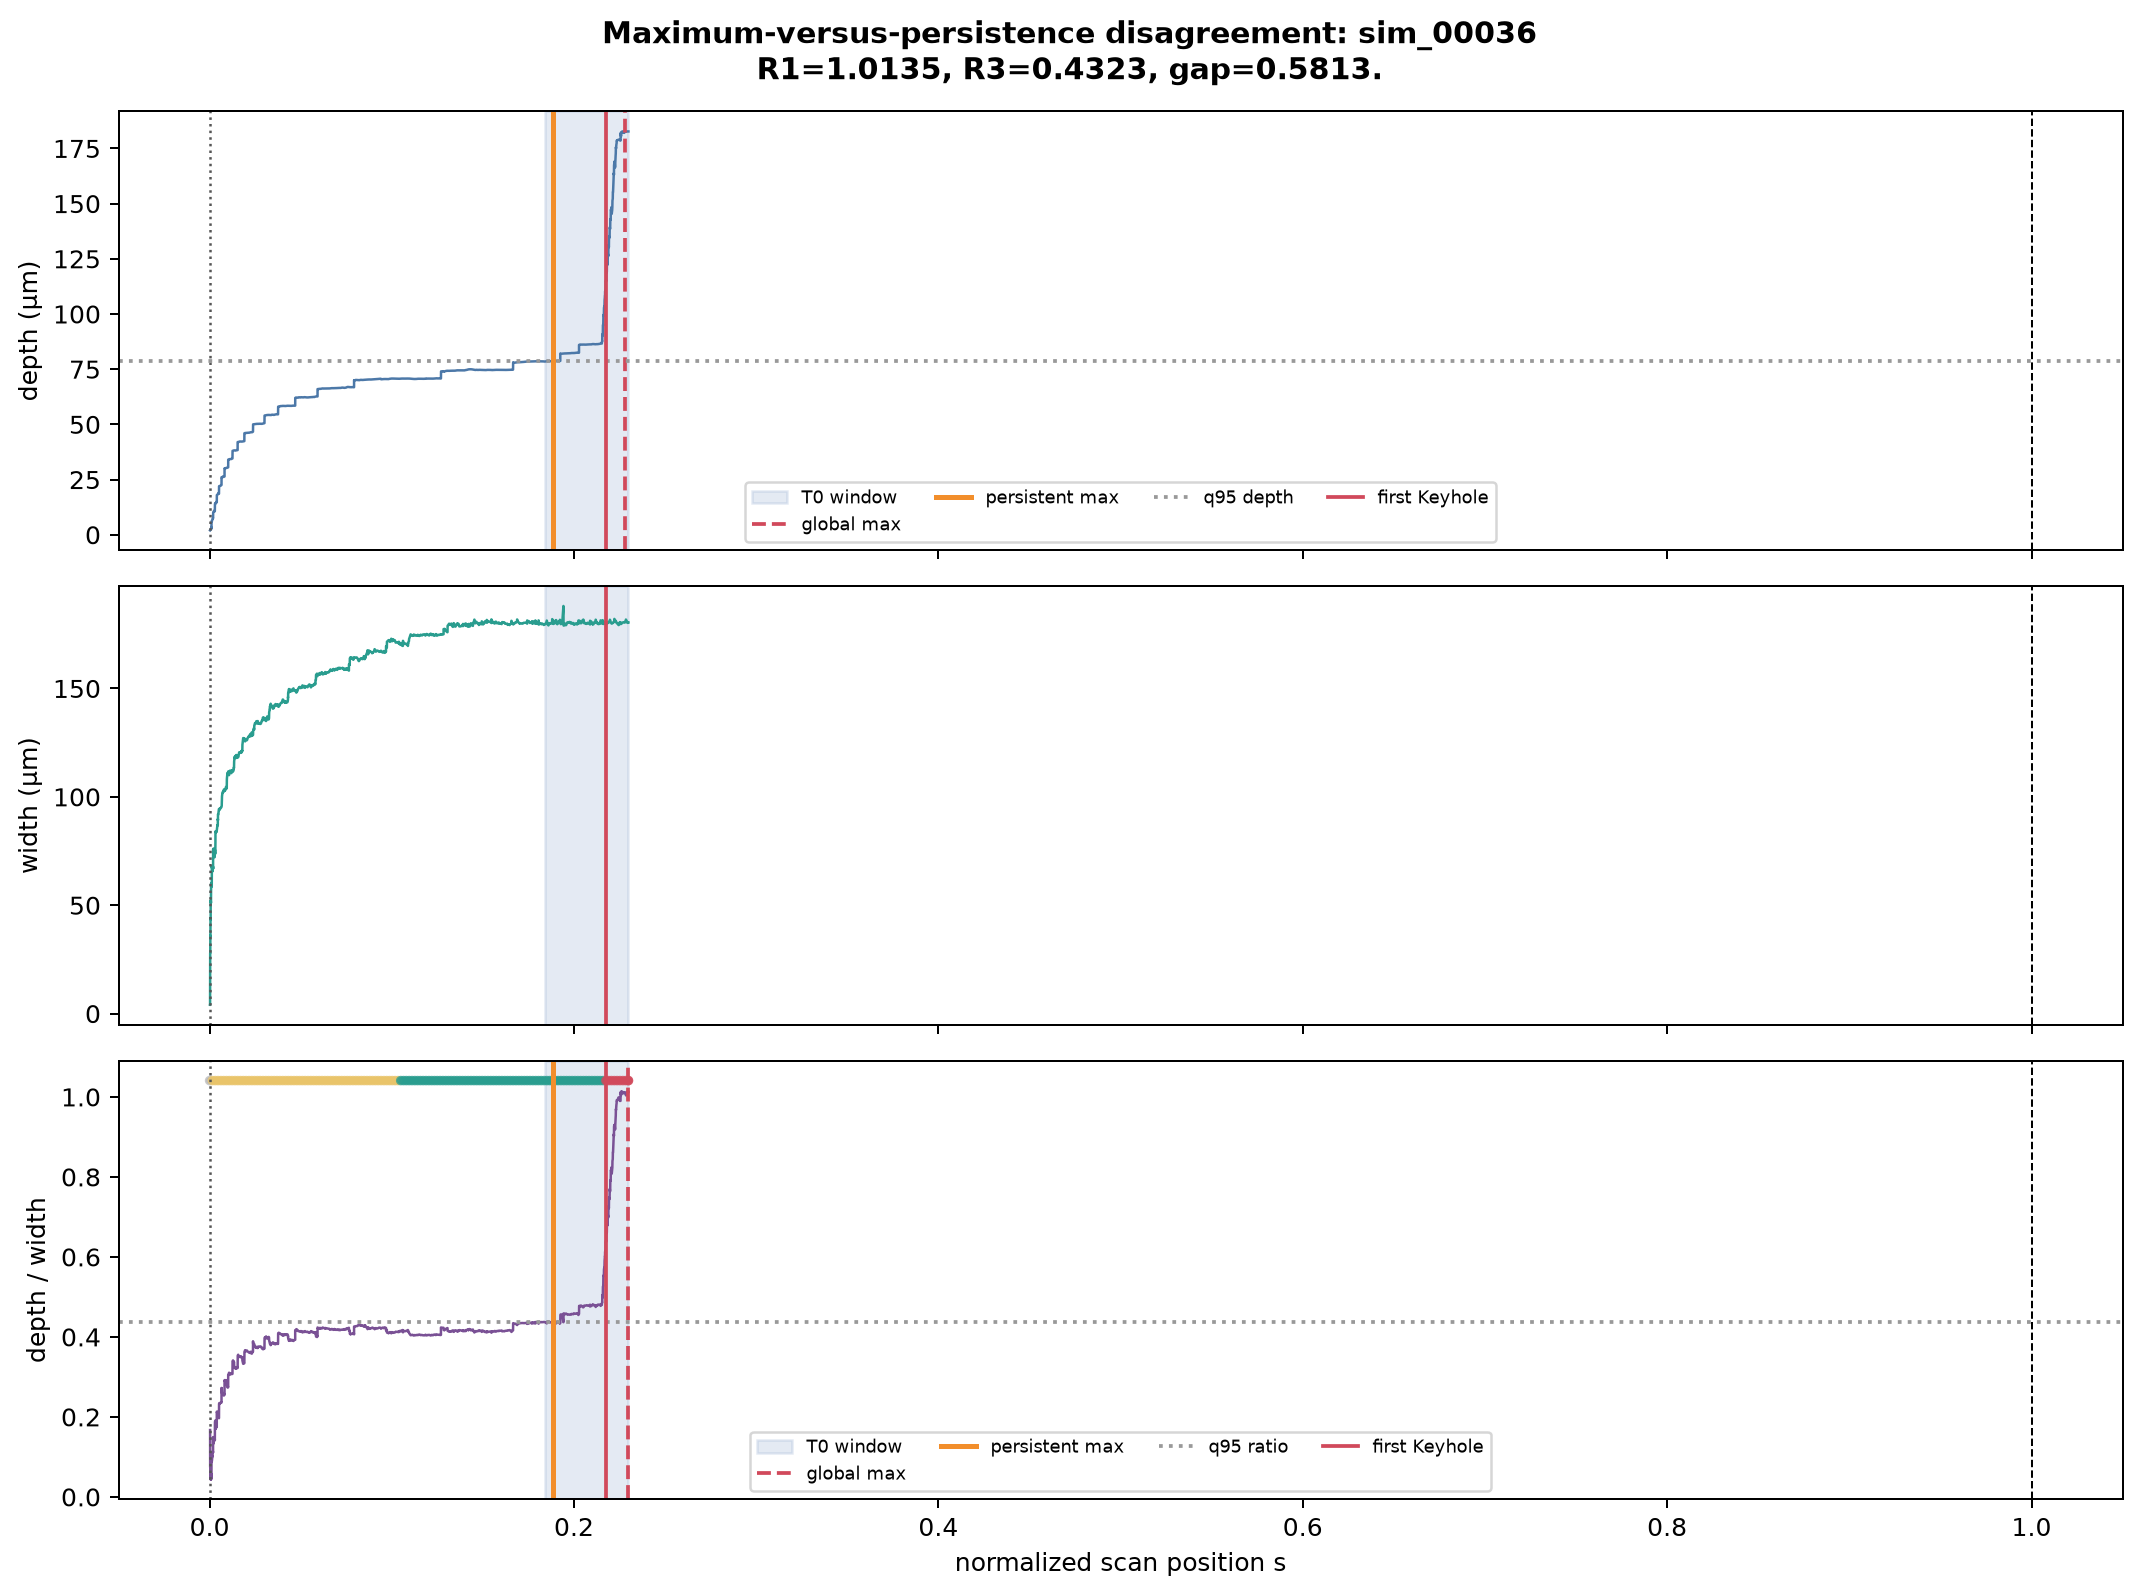

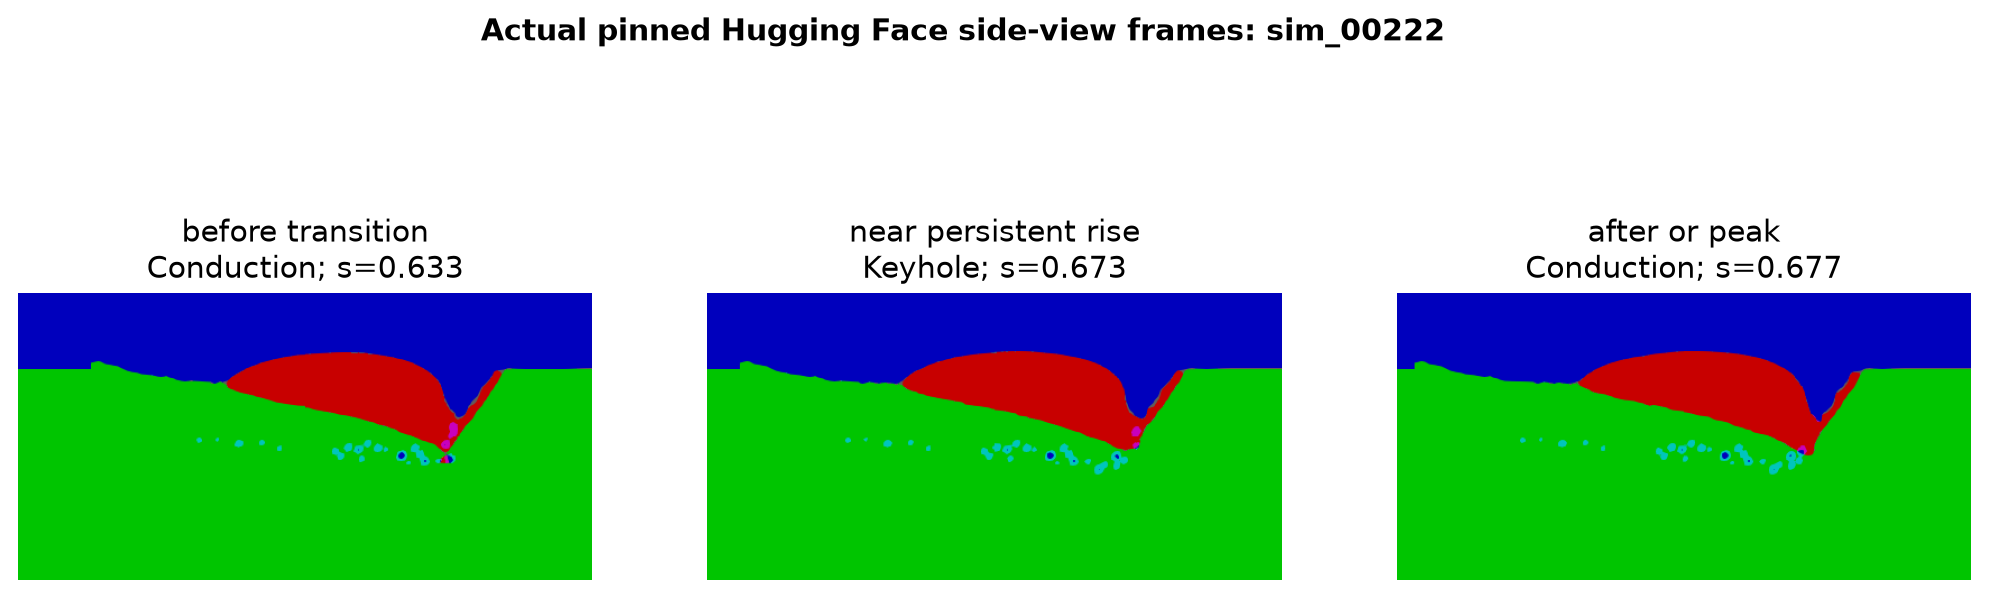

In [4]:
representatives = pd.read_csv(OUT / "representative_simulation_selection.csv")
display(representatives)
for name in [
    "28_case_typical_conduction_only.png",
    "29_case_typical_keyhole_containing.png",
    "30_case_mixed_conduction_to_keyhole.png",
    "31_case_spike_vs_persistent_disagreement.png",
]:
    display(Image(filename=str(OUT / "figures" / name)))
display(Image(filename=str(OUT / "figures" / "34_actual_frame_sequence_mixed_keyhole_case.png")))

The conduction, Keyhole-containing, mixed, and spike-disagreement cases
illustrate different reasons a scalar may succeed or fail. The three image
panels are actual files from the pinned Hugging Face revision. A case study is
an explanation aid, not a population estimate or independent label validation.

## D. Candidate regime-target construction

`G` candidates use absolute depth; `R` candidates use depth/width. Global
maxima are deliberately retained as spike-sensitive references. Persistence is
defined over physical distance, not a fixed number of monitor rows.

,candidate_id,candidate_name,machine_readable_definition,unit,role,caveat,primary_analysis_domain,primary_persistence_window_um,minimum_width_guard_um,higher_value_more_keyhole_like
0,G0,Existing Phase 1 T0 depth,Median penetration depth over the final 20% of...,um,geometry baseline,Typical late-active geometry; not designed as ...,Phase1_T0_window,NaN,NaN,True
1,G1,Global maximum depth,Maximum valid penetration depth over the compl...,um,spike-sensitive reference,Retained intentionally to expose isolated peak...,full_valid_track,NaN,NaN,True
2,G2,Interior q95 depth,95th percentile of penetration depth in the se...,um,robust high-depth summary,High but not explicitly persistent.,adaptive_active_interior,NaN,NaN,True
3,G3,Persistent maximum depth,Maximum trailing rolling median depth over a p...,um,primary persistent-depth candidate,"Persistence is physical-distance based, not ti...",adaptive_active_interior,50.0,NaN,True
4,G4,Persistent rolling-q80 depth,Maximum trailing rolling 80th-percentile depth...,um,robust-quantile sensitivity,"Sensitivity candidate, not searched post hoc.",adaptive_active_interior,50.0,NaN,True
5,R0,T0-window median aspect ratio,Median penetration depth divided by transverse...,dimensionless,geometry-ratio baseline,Uses the existing late-active window.,Phase1_T0_window,NaN,12.0,True
6,R1,Global maximum aspect ratio,Maximum valid depth/width over the complete ob...,dimensionless,spike-sensitive reference,Minimum-width guard is applied; still sensitiv...,full_valid_track,NaN,12.0,True
7,R2,Interior q95 aspect ratio,95th percentile of depth/width in the selected...,dimensionless,robust high-ratio candidate,High but not explicitly persistent.,adaptive_active_interior,NaN,12.0,True
8,R3,Persistent maximum aspect ratio,Maximum trailing rolling median depth/width ov...,dimensionless,primary persistent-ratio candidate,"Primary candidate, not a predetermined winner.",adaptive_active_interior,50.0,12.0,True
9,R4,Persistent high-ratio duration,Fraction of adaptive-interior scan distance ab...,fraction,threshold-dependent diagnostic,Outer-training geometry threshold is used for ...,adaptive_active_interior,NaN,12.0,True


,available,median_value
candidate_id,,
G0,241,54.753360
G1,241,55.165390
G2,240,54.947568
G3,240,54.907320
G4,240,54.997164
R0,241,0.334682
R1,241,0.351252
R2,240,0.346823
R3,240,0.345697


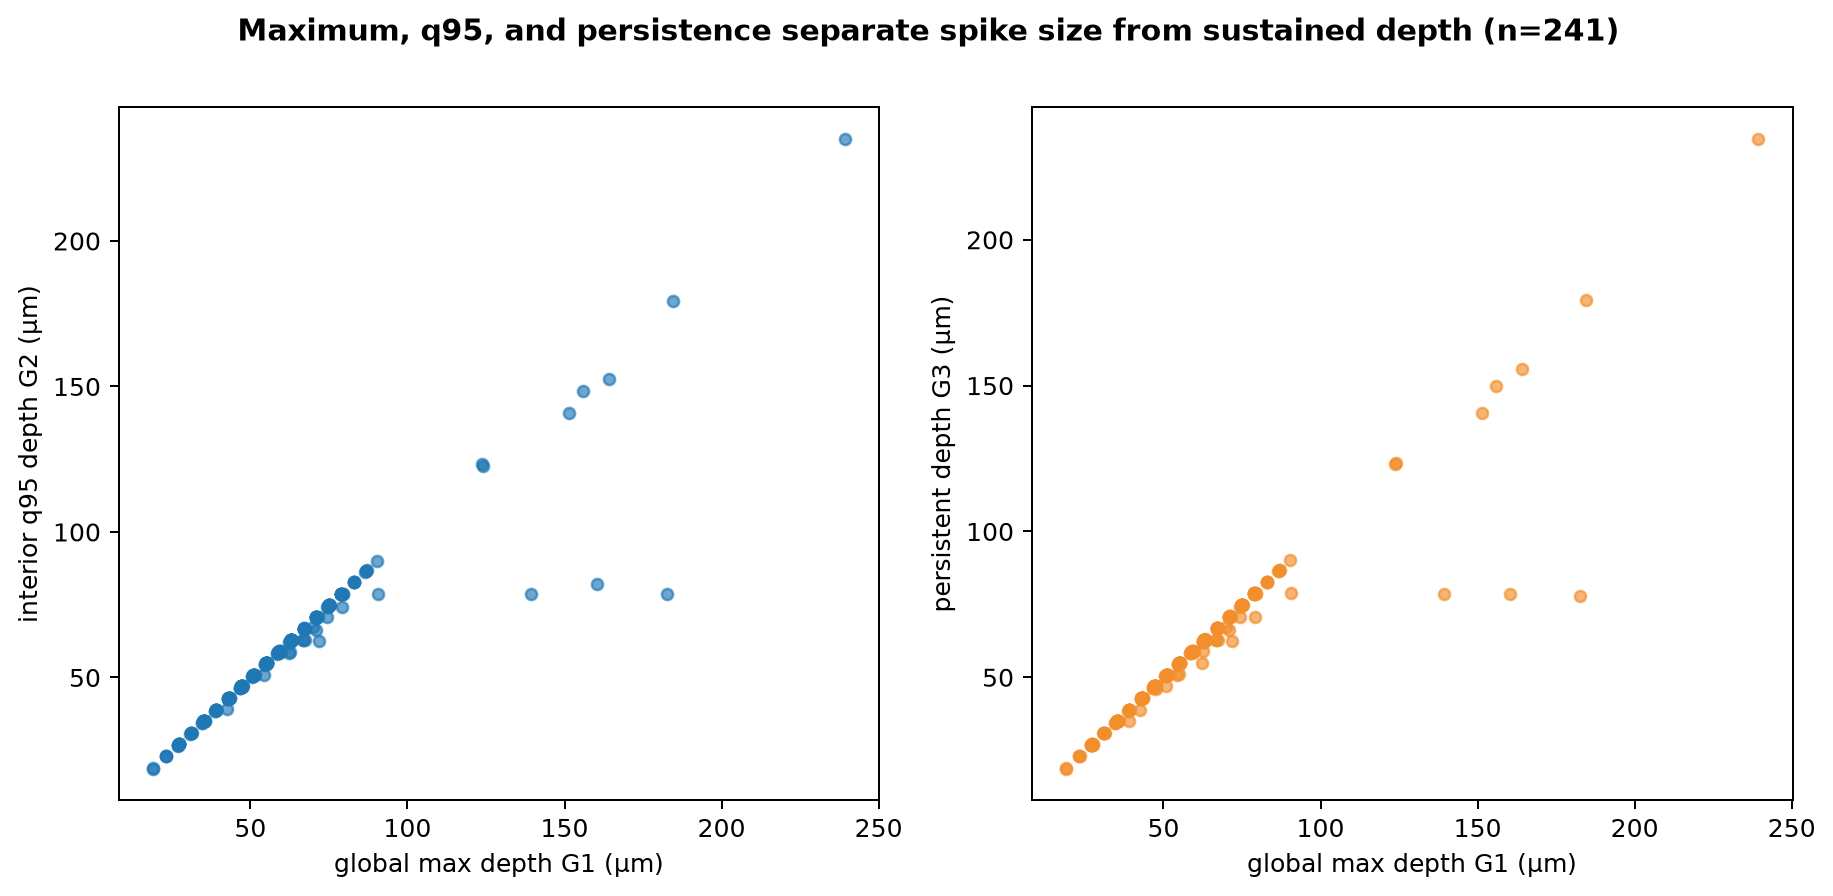

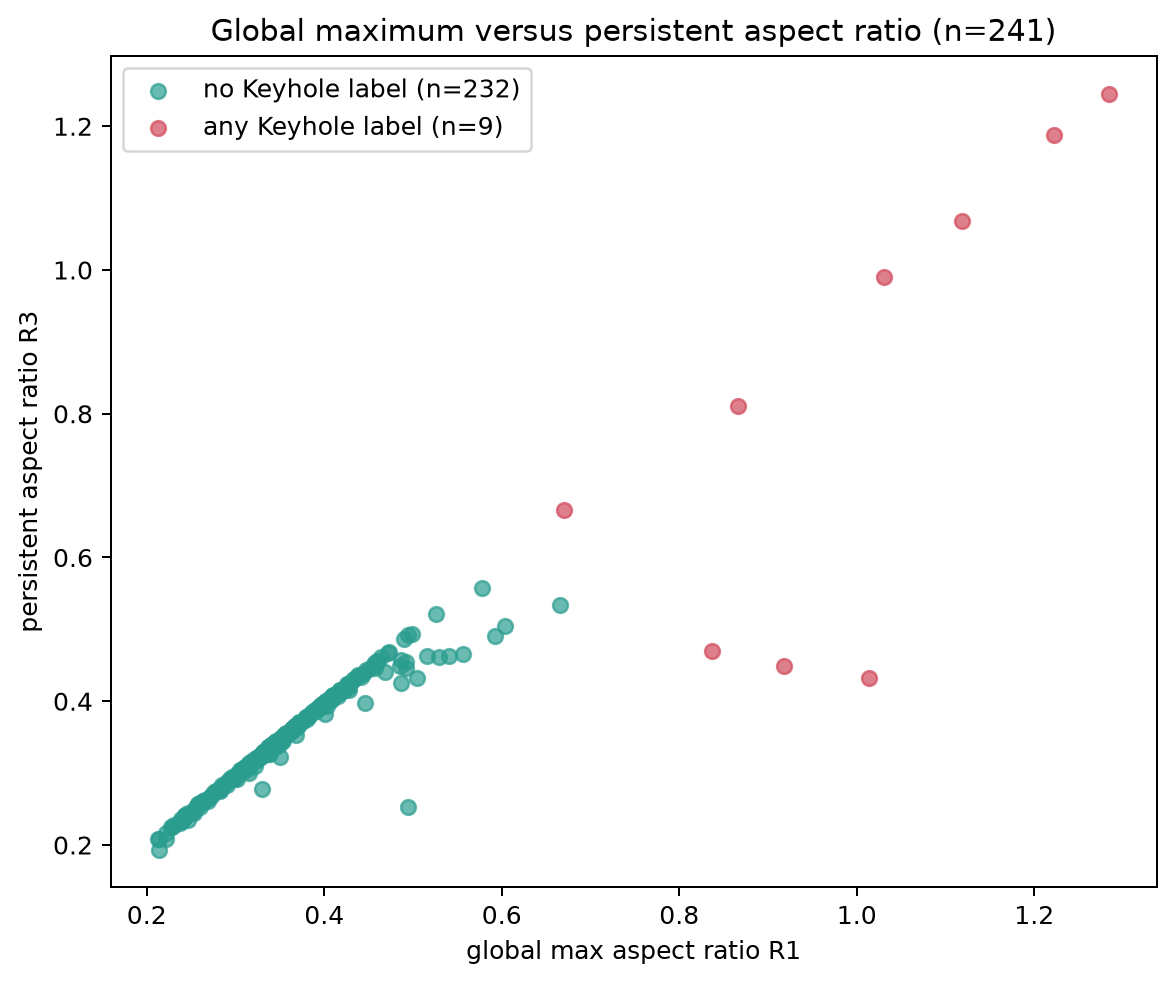

In [5]:
definitions = pd.read_csv(OUT / "regime_target_candidate_definitions.csv")
candidates = pd.read_csv(OUT / "regime_target_candidates.csv")
display(definitions)
display(candidates.groupby("candidate_id").agg(
    available=("available", "sum"),
    median_value=("value", "median"),
))
display(Image(filename=str(OUT / "figures" / "15_global_maximum_q95_persistent_depth_scatter.png")))
display(Image(filename=str(OUT / "figures" / "16_global_maximum_vs_persistent_aspect_ratio.png")))

Global maximum, q95, and rolling persistence are intentionally different.
The maximum answers “what was the single deepest observation?” while G3/R3
answer “what was the strongest geometry sustained across a physical window?”
No candidate is preferred solely because it is numerically larger.

## E. Candidate-versus-label evaluation

Frame-level intervals resample whole simulations. Simulation-level thresholds
use exact nested leave-one-simulation-out, so the held-out label never selects
its threshold.

,candidate,source_column,unit,orientation_multiplier,simulation_count,frame_count,positive_keyhole_frames,negative_conduction_frames,keyhole_simulation_count,roc_auc,pr_auc,prevalence_baseline,keyhole_median,conduction_median,rank_biserial_effect,forming_phase_excluded,technical_labels_excluded,alignment_scope
0,instantaneous_depth,depth_um,um,1.0,239,44400,521,43879,9,0.982418,0.762867,0.011734,136.044800,46.593650,0.964836,True,True,exact_iteration_matches_only
1,instantaneous_width_inverse,width_um,um; sign inverted for keyhole direction,-1.0,239,44400,521,43879,9,0.271540,0.007598,0.011734,155.433160,132.745090,-0.456920,True,True,exact_iteration_matches_only
2,instantaneous_aspect_ratio,aspect_ratio,dimensionless,1.0,239,44147,521,43626,9,0.983114,0.762442,0.011801,0.827536,0.318502,0.966227,True,True,exact_iteration_matches_only
3,instantaneous_depth_over_LS,depth_over_LS,dimensionless,1.0,239,44400,521,43879,9,0.994511,0.805919,0.011734,2.797340,0.723366,0.989022,True,True,exact_iteration_matches_only
4,local_rolling_depth_50um,rolling_median_depth_50um_um,um,1.0,239,43880,521,43359,9,0.984710,0.692691,0.011873,131.847200,46.677850,0.969419,True,True,exact_iteration_matches_only
5,local_rolling_aspect_ratio_50um,rolling_median_aspect_ratio_50um,dimensionless,1.0,239,43880,521,43359,9,0.984954,0.709463,0.011873,0.793581,0.319145,0.969907,True,True,exact_iteration_matches_only


,candidate_id,evaluation_score_column,outcome,simulation_count,positive_keyhole_simulations,negative_simulations,mixed_label_simulations,effective_sample_size,roc_auc,pr_auc,prevalence_baseline,comparison_type
0,G0,G0,any_keyhole,241,9,232,8,241,0.967433,0.677551,0.037344,fixed continuous score
1,G1,G1,any_keyhole,241,9,232,8,241,1.000000,1.000000,0.037344,fixed continuous score
2,G2,G2,any_keyhole,240,9,231,8,240,0.975469,0.762774,0.037500,fixed continuous score
3,G3,G3,any_keyhole,240,9,231,8,240,0.971140,0.761702,0.037500,fixed continuous score
4,G4,G4,any_keyhole,240,9,231,8,240,0.975950,0.778647,0.037500,fixed continuous score
5,R0,R0,any_keyhole,241,9,232,8,241,0.986111,0.770301,0.037344,fixed continuous score
6,R1,R1,any_keyhole,241,9,232,8,241,1.000000,1.000000,0.037344,fixed continuous score
7,R2,R2,any_keyhole,240,9,231,8,240,0.977874,0.797122,0.037500,fixed continuous score
8,R3,R3,any_keyhole,240,9,231,8,240,0.969216,0.771002,0.037500,fixed continuous score
9,R4,R4_LOO,any_keyhole,240,9,231,8,240,0.912939,0.465227,0.037500,leakage-safe outer-training geometry threshold


,candidate_id,heldout_simulations,positive_count,negative_count,balanced_accuracy,sensitivity,specificity,precision,recall,f1,true_negative,false_positive,false_negative,true_positive,evaluation,leakage_safe
0,G0,241,9,232,0.860872,0.777778,0.943966,0.350000,0.777778,0.482759,219,13,2,7,exact nested leave-one-simulation-out,True
1,G2,240,9,231,0.956710,1.000000,0.913420,0.310345,1.000000,0.473684,211,20,0,9,exact nested leave-one-simulation-out,True
2,G3,240,9,231,0.956710,1.000000,0.913420,0.310345,1.000000,0.473684,211,20,0,9,exact nested leave-one-simulation-out,True
3,R2,240,9,231,0.879509,0.888889,0.870130,0.210526,0.888889,0.340426,201,30,1,8,exact nested leave-one-simulation-out,True
4,R3,240,9,231,0.873016,0.888889,0.857143,0.195122,0.888889,0.320000,198,33,1,8,exact nested leave-one-simulation-out,True


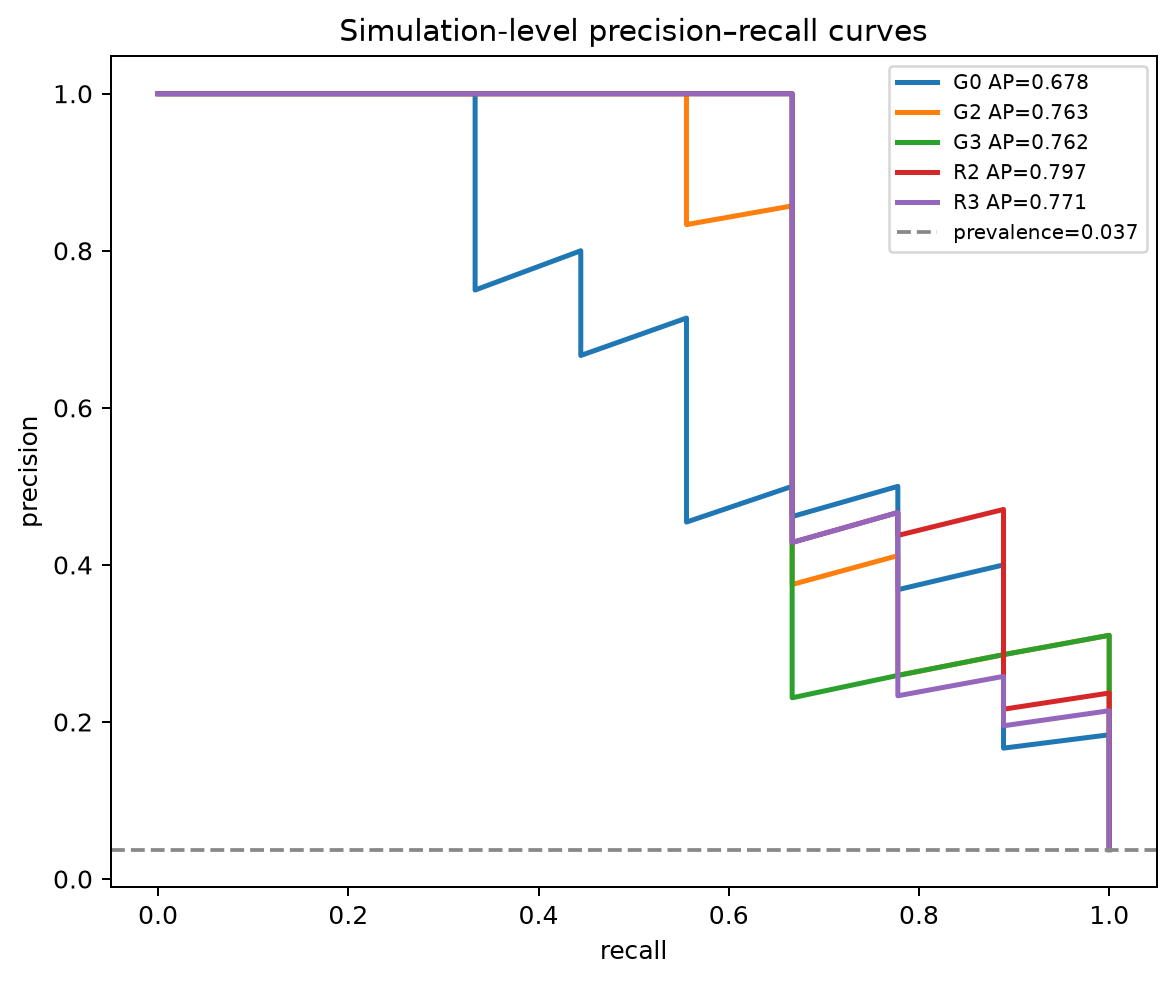

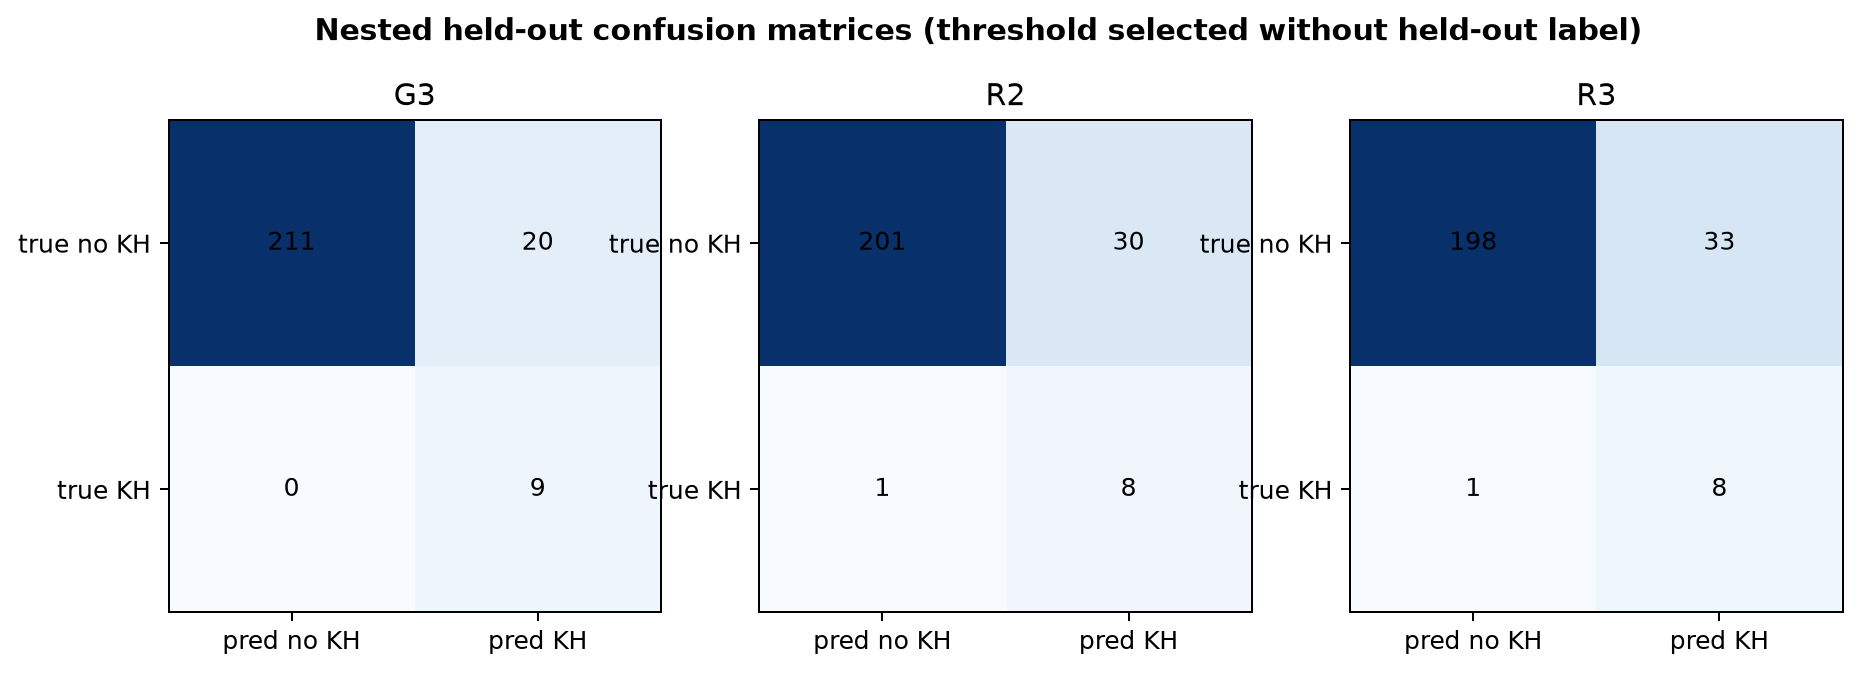

In [6]:
frame_metrics = pd.read_csv(OUT / "frame_level_candidate_label_metrics.csv")
simulation_metrics = pd.read_csv(OUT / "simulation_level_candidate_label_metrics.csv")
nested_metrics = pd.read_csv(OUT / "nested_threshold_metrics.csv")
display(frame_metrics)
display(simulation_metrics)
display(nested_metrics)
display(Image(filename=str(OUT / "figures" / "23_candidate_precision_recall_curves_with_prevalence.png")))
display(Image(filename=str(OUT / "figures" / "25_nested_heldout_confusion_matrices.png")))

ROC and PR results quantify agreement with the current labels, not physical
truth. PR AUC is compared with the prevalence baseline because only 9/241
simulations are positive. Perfect or near-perfect ranking by a depth maximum is
not decisive: the labels were initially depth-seeded and the maximum remains
spike-sensitive.

## F. Robustness and sensitivity checks

The analysis predeclares 20, 50, and 100 µm windows plus 1%, 2.5%, and 5% of
track length. It also compares common/adaptive interiors, three width guards,
the 241/230 populations, coverage groups, and VX strata.

,simulation_id,analysis_domain,window_type,window_value,window_distance_um,candidate_id,value,unit,event_position_s,available,...,record_type,availability_count,availability_fraction,median_value,roc_auc_any_keyhole,pr_auc_any_keyhole,prevalence,positive_count,negative_count,median_window_observation_count
8658,NaN,adaptive_active_interior,normalized_track_fraction,1.0,12.12,G3,NaN,um,NaN,True,...,summary,240.0,1.000000,55.013645,0.976912,0.781089,0.037500,9.0,231.0,1068.5
8659,NaN,adaptive_active_interior,normalized_track_fraction,1.0,12.12,G4,NaN,um,NaN,True,...,summary,240.0,1.000000,55.072957,0.980760,0.831293,0.037500,9.0,231.0,1068.5
8660,NaN,adaptive_active_interior,normalized_track_fraction,1.0,12.12,R3,NaN,dimensionless,NaN,True,...,summary,240.0,1.000000,0.348376,0.977393,0.799074,0.037500,9.0,231.0,1068.5
8661,NaN,adaptive_active_interior,normalized_track_fraction,2.5,30.30,G3,NaN,um,NaN,True,...,summary,240.0,1.000000,54.948445,0.972102,0.764007,0.037500,9.0,231.0,2671.0
8662,NaN,adaptive_active_interior,normalized_track_fraction,2.5,30.30,G4,NaN,um,NaN,True,...,summary,240.0,1.000000,55.021240,0.975950,0.778647,0.037500,9.0,231.0,2671.0
8663,NaN,adaptive_active_interior,normalized_track_fraction,2.5,30.30,R3,NaN,dimensionless,NaN,True,...,summary,240.0,1.000000,0.346666,0.970659,0.773148,0.037500,9.0,231.0,2671.0
8664,NaN,adaptive_active_interior,normalized_track_fraction,5.0,60.60,G3,NaN,um,NaN,True,...,summary,240.0,1.000000,54.895002,0.970178,0.759477,0.037500,9.0,231.0,5341.5
8665,NaN,adaptive_active_interior,normalized_track_fraction,5.0,60.60,G4,NaN,um,NaN,True,...,summary,240.0,1.000000,54.980318,0.975950,0.778647,0.037500,9.0,231.0,5341.5
8666,NaN,adaptive_active_interior,normalized_track_fraction,5.0,60.60,R3,NaN,dimensionless,NaN,True,...,summary,240.0,1.000000,0.345012,0.965368,0.764360,0.037500,9.0,231.0,5341.5
8667,NaN,adaptive_active_interior,physical_um,20.0,20.00,G3,NaN,um,NaN,True,...,summary,240.0,1.000000,54.984015,0.975950,0.778647,0.037500,9.0,231.0,1763.5


,simulation_id,analysis_domain,candidate_id,value,unit,available,event_position_s,any_keyhole,record_type,sensitivity_type,availability_count,availability_fraction,median_value,roc_auc_any_keyhole,pr_auc_any_keyhole,prevalence,positive_count,negative_count,minimum_width_guard_um,invalid_ratio_row_count
2410,NaN,adaptive_active_interior,G2,NaN,um,False,NaN,NaN,summary,analysis_domain,240.0,0.995851,54.947568,0.975469,0.762774,0.037500,9.0,231.0,NaN,NaN
2411,NaN,adaptive_active_interior,G3,NaN,um,False,NaN,NaN,summary,analysis_domain,240.0,0.995851,54.907320,0.971140,0.761702,0.037500,9.0,231.0,NaN,NaN
2412,NaN,adaptive_active_interior,G4,NaN,um,False,NaN,NaN,summary,analysis_domain,240.0,0.995851,54.997164,0.975950,0.778647,0.037500,9.0,231.0,NaN,NaN
2413,NaN,adaptive_active_interior,R2,NaN,dimensionless,False,NaN,NaN,summary,analysis_domain,240.0,0.995851,0.346823,0.977874,0.797122,0.037500,9.0,231.0,NaN,NaN
2414,NaN,adaptive_active_interior,R3,NaN,dimensionless,False,NaN,NaN,summary,analysis_domain,240.0,0.995851,0.345697,0.969216,0.771002,0.037500,9.0,231.0,NaN,NaN
2415,NaN,common_interior,G2,NaN,um,True,NaN,NaN,summary,analysis_domain,241.0,1.000000,54.910665,0.999042,0.976543,0.037344,9.0,232.0,NaN,NaN
2416,NaN,common_interior,G3,NaN,um,True,NaN,NaN,summary,analysis_domain,241.0,1.000000,54.872210,0.997126,0.939577,0.037344,9.0,232.0,NaN,NaN
2417,NaN,common_interior,G4,NaN,um,True,NaN,NaN,summary,analysis_domain,241.0,1.000000,54.936886,0.999042,0.976543,0.037344,9.0,232.0,NaN,NaN
2418,NaN,common_interior,R2,NaN,dimensionless,True,NaN,NaN,summary,analysis_domain,241.0,1.000000,0.346008,0.997126,0.955556,0.037344,9.0,232.0,NaN,NaN
2419,NaN,common_interior,R3,NaN,dimensionless,True,NaN,NaN,summary,analysis_domain,241.0,1.000000,0.344766,0.994253,0.907937,0.037344,9.0,232.0,NaN,NaN


,population,candidate_id,simulation_count,excluded_simulation_count,excluded_simulation_ids,positive_count,negative_count,roc_auc,pr_auc,prevalence,median_value
0,all_241,G0,241,0,NaN,9,232,0.967433,0.677551,0.037344,54.753360
1,all_241,G1,241,0,NaN,9,232,1.000000,1.000000,0.037344,55.165390
2,all_241,G2,240,0,NaN,9,231,0.975469,0.762774,0.037500,54.947568
3,all_241,G3,240,0,NaN,9,231,0.971140,0.761702,0.037500,54.907320
4,all_241,G4,240,0,NaN,9,231,0.975950,0.778647,0.037500,54.997164
5,all_241,R0,241,0,NaN,9,232,0.986111,0.770301,0.037344,0.334682
6,all_241,R1,241,0,NaN,9,232,1.000000,1.000000,0.037344,0.351252
7,all_241,R2,240,0,NaN,9,231,0.977874,0.797122,0.037500,0.346823
8,all_241,R3,240,0,NaN,9,231,0.969216,0.771002,0.037500,0.345697
9,all_241,R4,240,0,NaN,9,231,0.914863,0.475658,0.037500,0.000000


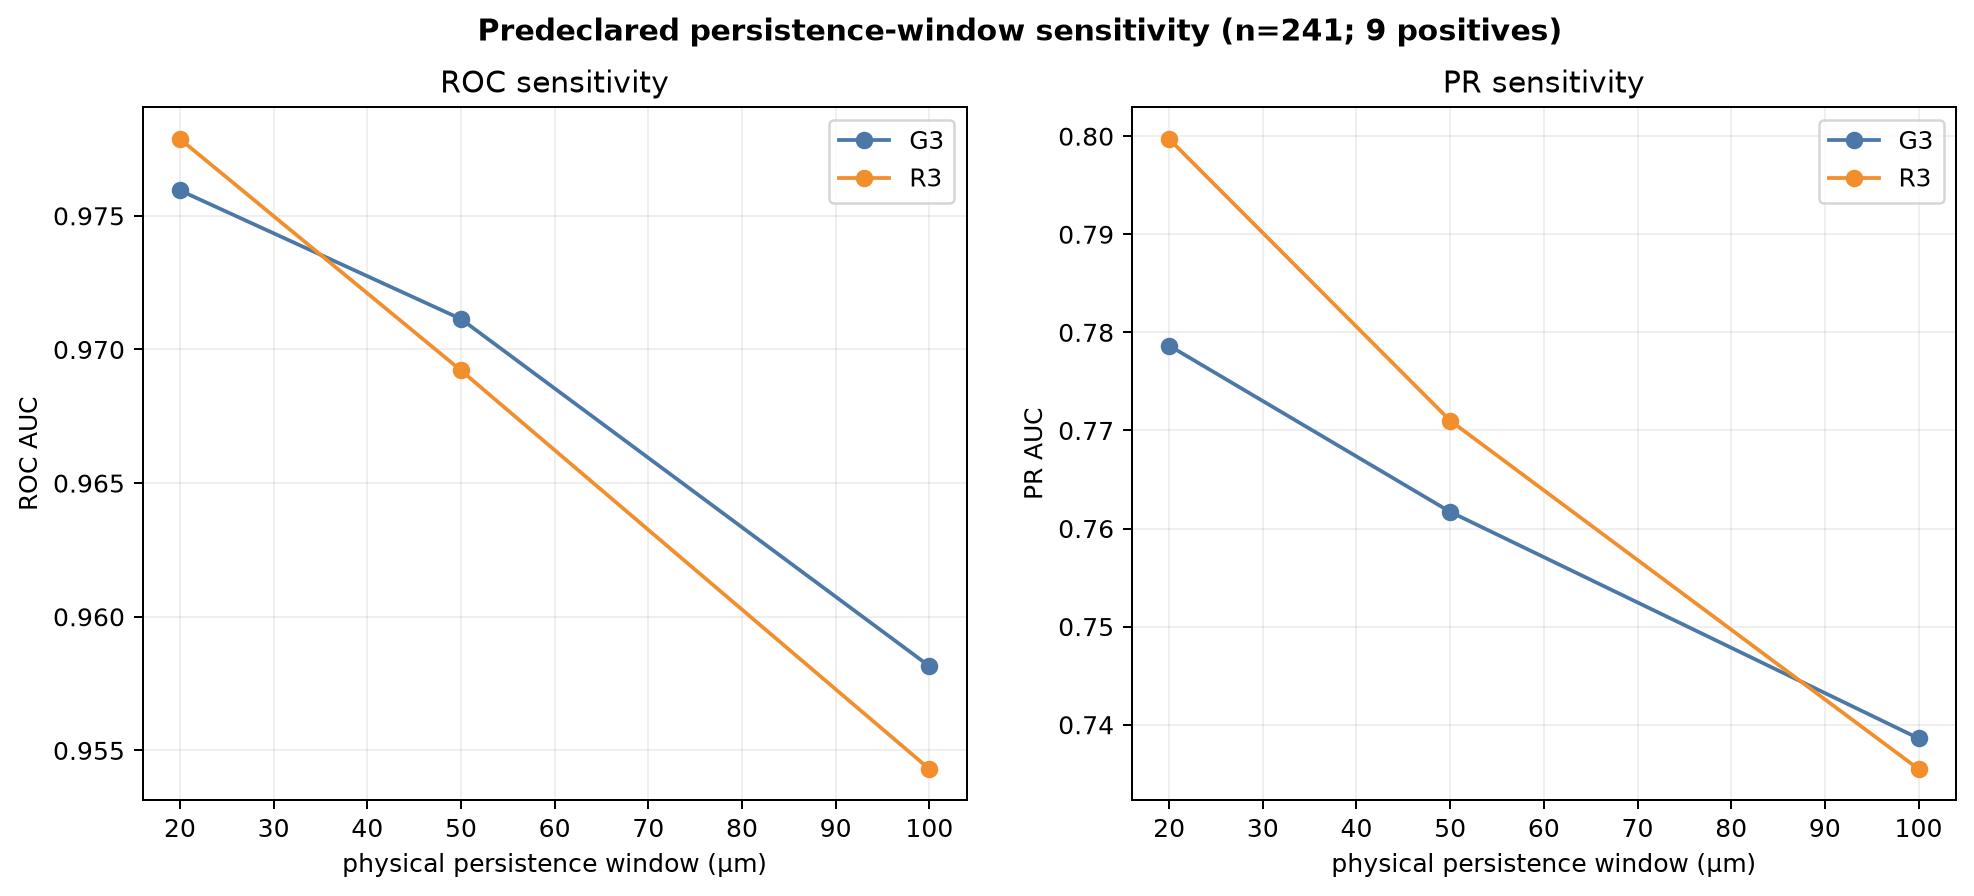

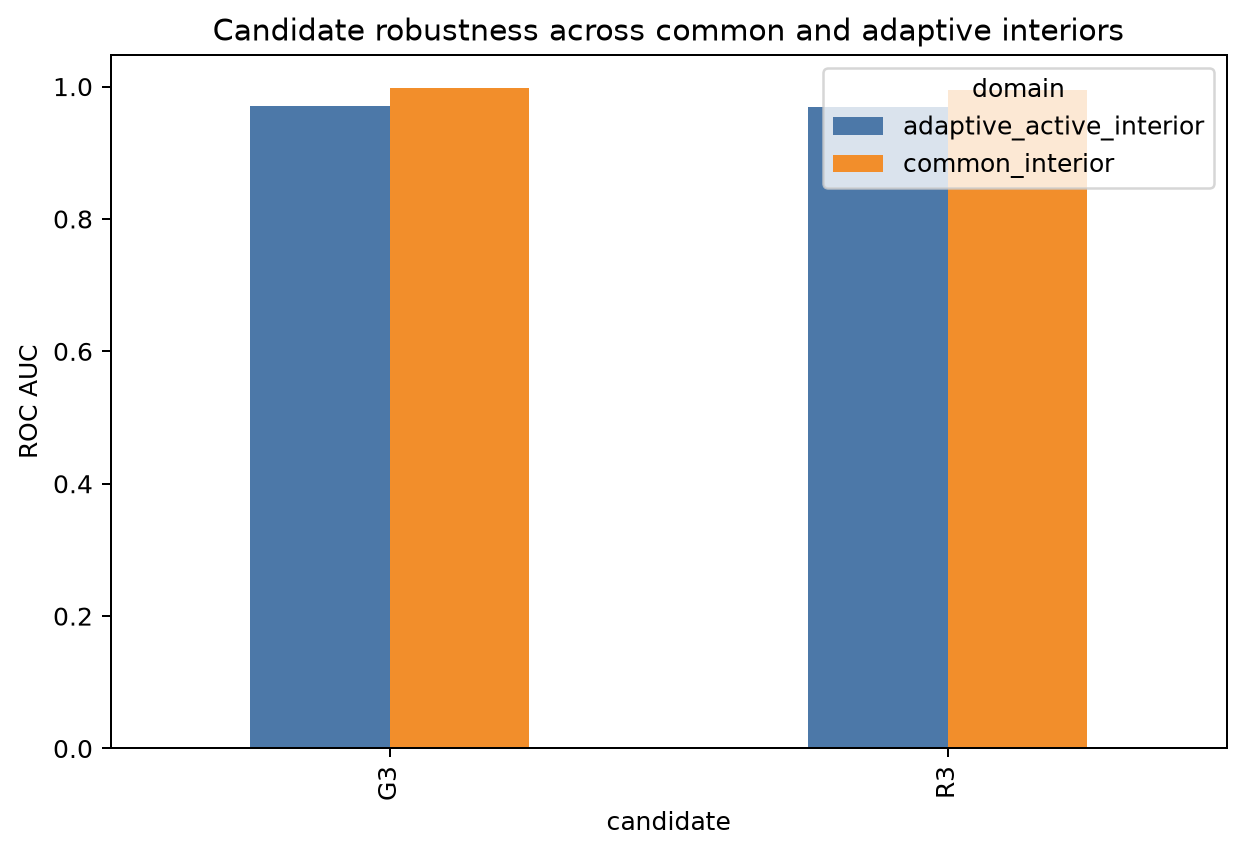

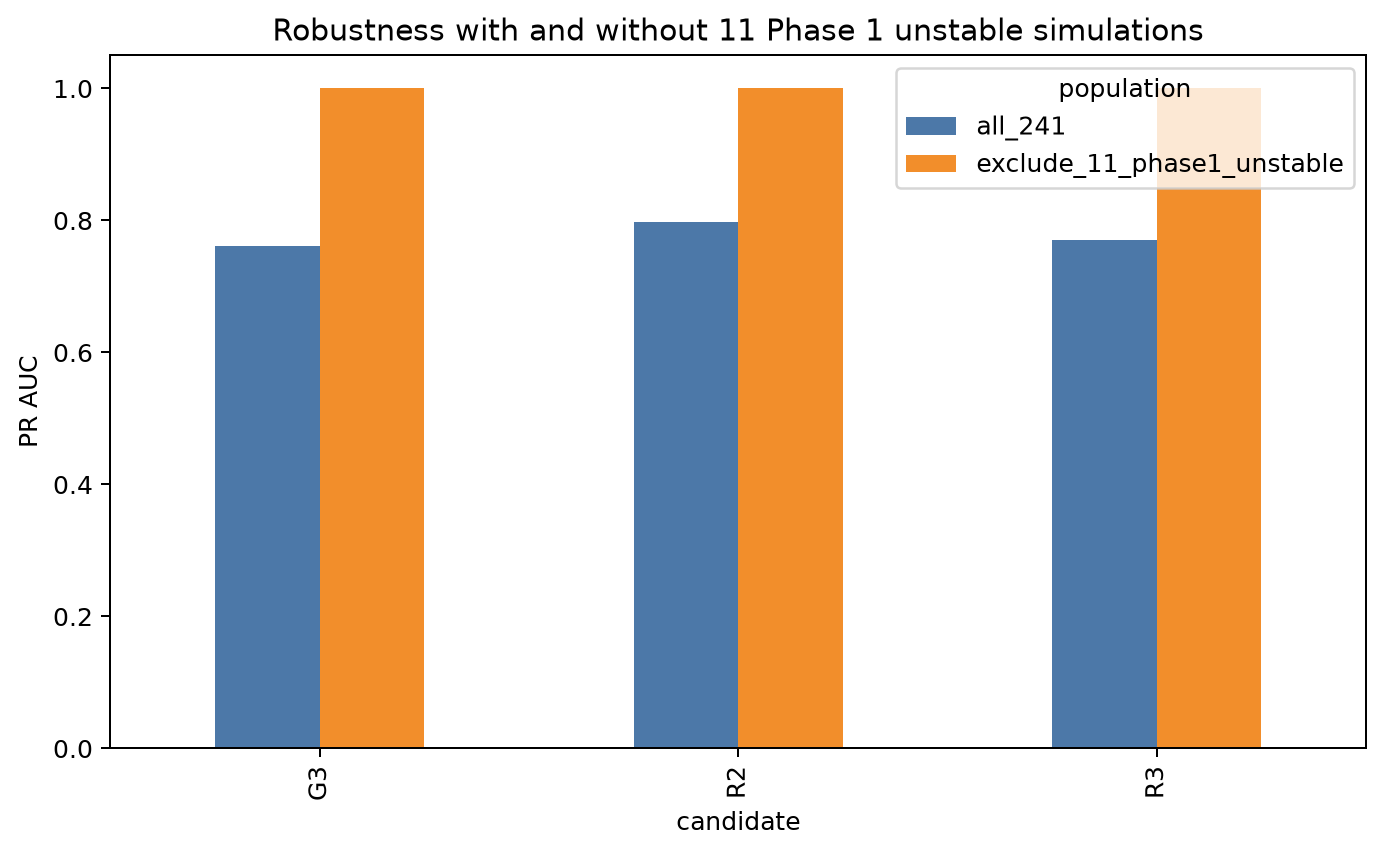

In [7]:
persistence = pd.read_csv(OUT / "persistence_window_sensitivity.csv")
domain = pd.read_csv(OUT / "candidate_domain_sensitivity.csv")
unstable = pd.read_csv(OUT / "candidate_unstable_subset_sensitivity.csv")
censoring = pd.read_csv(OUT / "candidate_censoring_sensitivity.csv")
display(persistence[persistence["record_type"].eq("summary")])
display(domain[domain["record_type"].eq("summary")])
display(unstable)
display(Image(filename=str(OUT / "figures" / "17_persistence_window_sensitivity.png")))
display(Image(filename=str(OUT / "figures" / "26_candidate_robustness_across_analysis_domains.png")))
display(Image(filename=str(OUT / "figures" / "27_candidate_robustness_with_without_unstable_simulations.png")))

These checks prevent a post-hoc “best window” story. R3 is interpreted at 50
µm only alongside the other predeclared scales. Large changes across windows,
domains, censoring groups, or unstable exclusions would weaken the
recommendation even if one AUC looked strong.

## G. Final target recommendation

Evidence dimensions remain separate. The decision matrix does not hide
physical interpretation, spike robustness, coverage, and label agreement
inside an arbitrary weighted score.

,candidate_id,candidate_name,physical_suitability,sensitivity_to_deep_keyhole_like_geometry,spike_robustness,temporal_window_robustness,coverage_and_censoring,implementation_simplicity,active_learning_suitability,simulation_roc_auc,...,pr_prevalence_baseline,roc_auc_ci,pr_auc_ci,availability_count,availability_fraction,window_auc_range,domain_auc_range,recommended_role,label_evidence_status,unweighted_decision_note
0,G0,Existing Phase 1 T0 depth,strong,weak,strong,not_applicable,strong,strong,strong,0.967433,...,0.037344,"[0.922, 0.996]","[0.365, 0.917]",241,1.000000,NaN,NaN,baseline,descriptive_only_depth_seeded_and_sparse,No numerical weights are assigned; columns ret...
1,G1,Global maximum depth,strong,strong,weak,not_applicable,strong,strong,weak,1.000000,...,0.037344,"[1.000, 1.000]","[1.000, 1.000]",241,1.000000,NaN,NaN,reference_only,descriptive_only_depth_seeded_and_sparse,No numerical weights are assigned; columns ret...
2,G2,Interior q95 depth,strong,strong,moderate,not_applicable,strong,strong,strong,0.975469,...,0.037500,"[0.944, 1.000]","[0.467, 1.000]",240,0.995851,NaN,0.023573,leading_candidate,descriptive_only_depth_seeded_and_sparse,No numerical weights are assigned; columns ret...
3,G3,Persistent maximum depth,strong,strong,strong,strong,strong,moderate,strong,0.971140,...,0.037500,"[0.935, 1.000]","[0.464, 1.000]",240,0.995851,0.018759,0.025986,companion_candidate,descriptive_only_depth_seeded_and_sparse,No numerical weights are assigned; columns ret...
4,G4,Persistent rolling-q80 depth,strong,strong,strong,strong,strong,moderate,moderate,0.975950,...,0.037500,"[0.944, 1.000]","[0.496, 1.000]",240,0.995851,0.010101,0.023092,sensitivity_only,descriptive_only_depth_seeded_and_sparse,No numerical weights are assigned; columns ret...
5,R0,T0-window median aspect ratio,strong,moderate,strong,not_applicable,strong,strong,strong,0.986111,...,0.037344,"[0.968, 0.998]","[0.488, 0.956]",241,1.000000,NaN,NaN,baseline,descriptive_only_depth_seeded_and_sparse,No numerical weights are assigned; columns ret...
6,R1,Global maximum aspect ratio,strong,strong,weak,not_applicable,strong,strong,weak,1.000000,...,0.037344,"[1.000, 1.000]","[1.000, 1.000]",241,1.000000,NaN,NaN,reference_only,descriptive_only_depth_seeded_and_sparse,No numerical weights are assigned; columns ret...
7,R2,Interior q95 aspect ratio,strong,strong,moderate,not_applicable,strong,strong,strong,0.977874,...,0.037500,"[0.943, 1.000]","[0.511, 1.000]",240,0.995851,NaN,0.019252,leading_candidate,descriptive_only_depth_seeded_and_sparse,No numerical weights are assigned; columns ret...
8,R3,Persistent maximum aspect ratio,strong,strong,strong,strong,strong,moderate,strong,0.969216,...,0.037500,"[0.925, 1.000]","[0.478, 1.000]",240,0.995851,0.023569,0.025037,provisional_regime_target,descriptive_only_depth_seeded_and_sparse,No numerical weights are assigned; columns ret...
9,R4,Persistent high-ratio duration,moderate,strong,moderate,not_applicable,strong,weak,moderate,0.912939,...,0.037500,"[0.783, 0.987]","[0.177, 0.779]",240,0.995851,NaN,NaN,threshold_diagnostic,descriptive_only_depth_seeded_and_sparse,No numerical weights are assigned; columns ret...


,response_role,recommended_target,status,physical_quantity,reason,label_validation_status,requires_ioan_confirmation
0,geometry_target,G0 / existing Phase 1 T0 geometry targets,retain,typical late-active geometry,T0 remains interpretable and was not designed ...,not dependent on Keyhole labels,False
1,regime_propensity_target,R3 persistent maximum depth/width over 50 um,provisional_recommendation,largest sustained penetration-depth-to-width r...,"Combines depth and width, suppresses isolated ...",descriptive only: 9 Keyhole-positive simulatio...,True
2,regime_companion_sensitivity,G3 persistent maximum depth over 50 um,retain_as_companion,largest sustained penetration depth,Avoids aspect-ratio denominator concerns and s...,descriptive only and especially circular with ...,True
3,later_active_learning_design,two-output representation,recommended_design_not_implemented,typical geometry plus persistent regime propen...,One scalar would conflate ordinary geometry wi...,requires updated independent labels,True


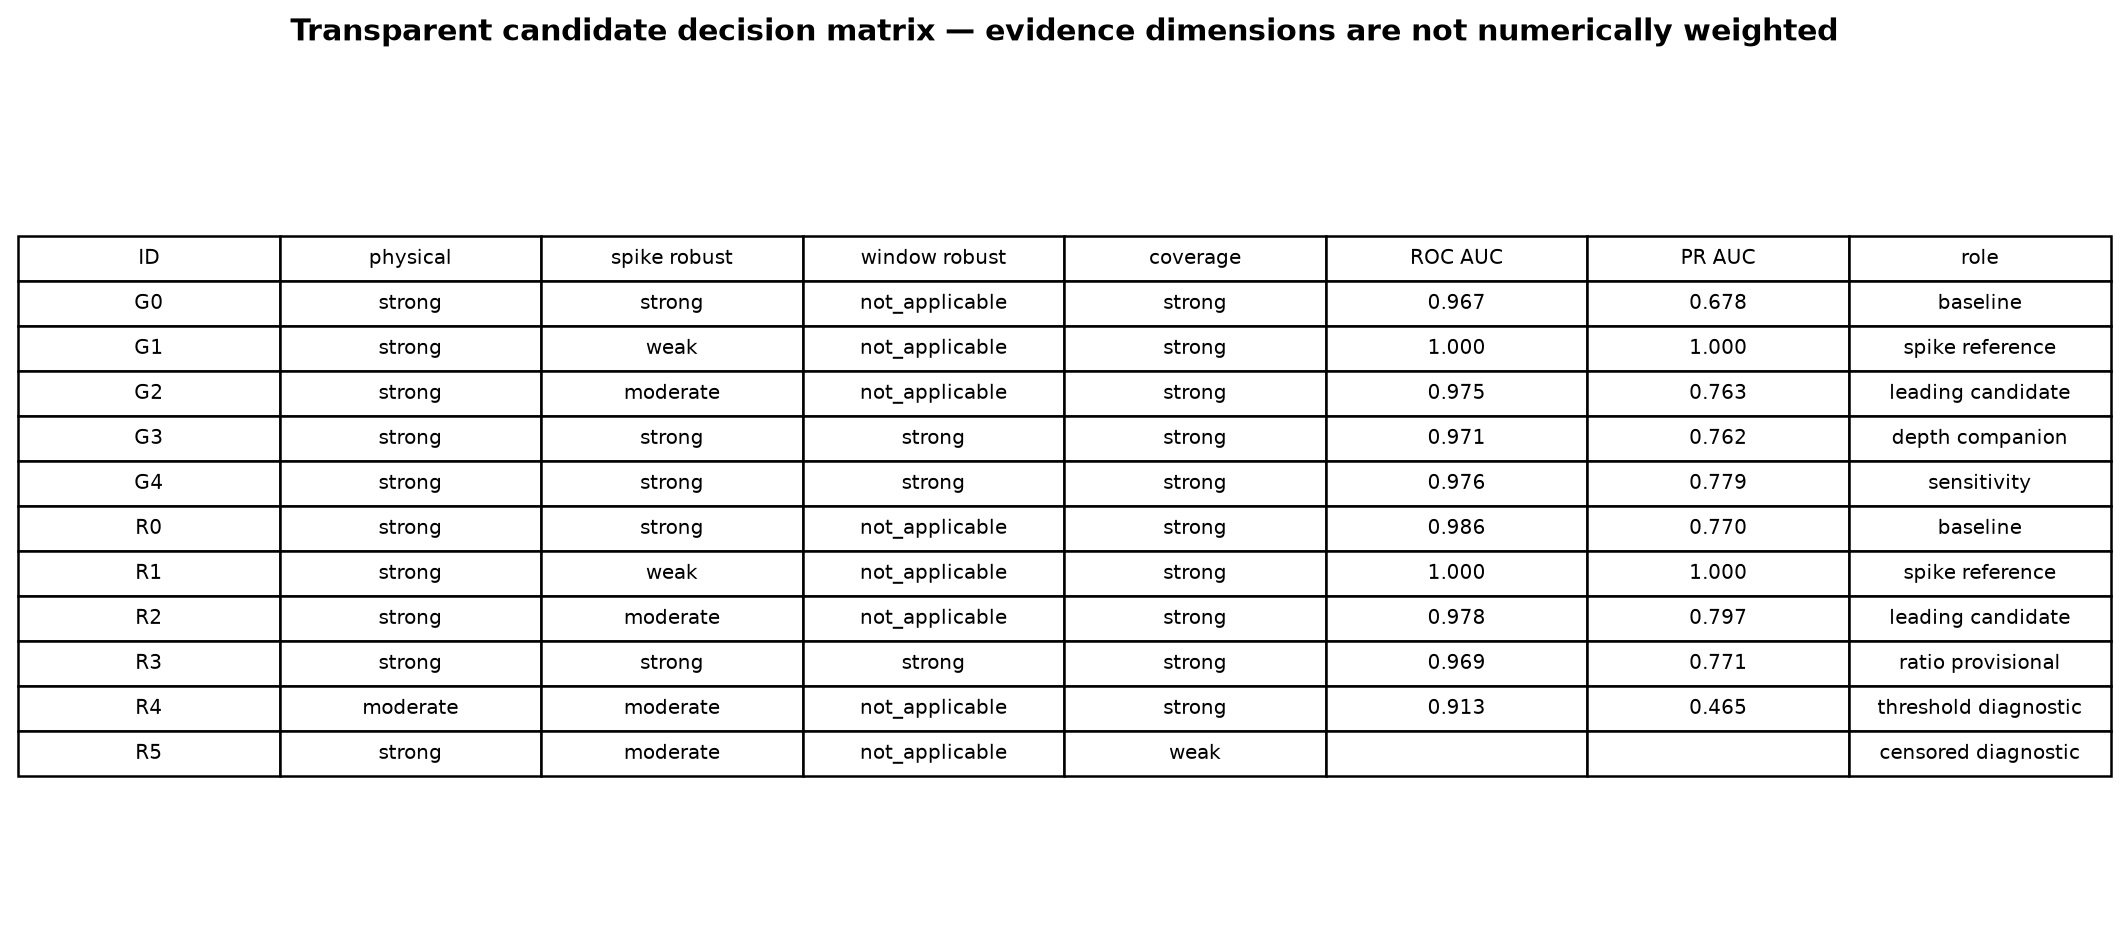

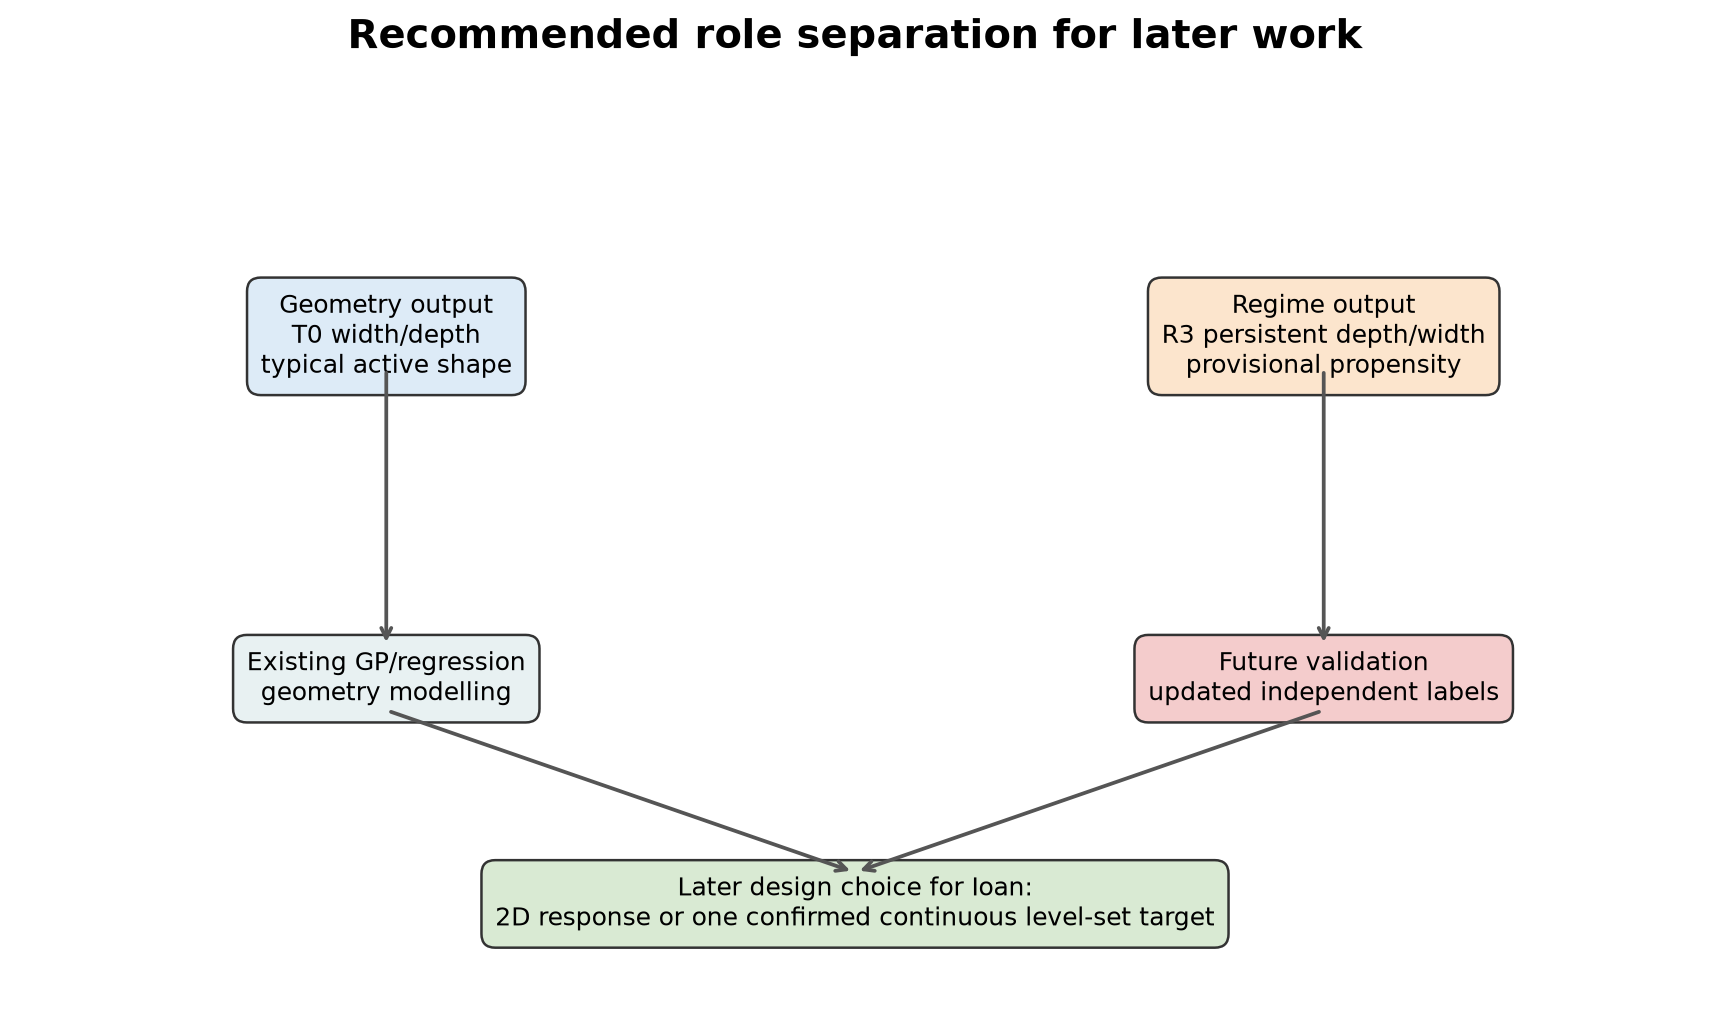

In [8]:
decision = pd.read_csv(OUT / "phase3_5_candidate_decision_matrix.csv")
recommendation = pd.read_csv(OUT / "phase3_5_final_target_recommendation.csv")
display(decision)
display(recommendation)
display(Image(filename=str(OUT / "figures" / "36_final_candidate_decision_matrix.png")))
display(Image(filename=str(OUT / "figures" / "37_final_recommended_geometry_regime_active_learning_roles.png")))

The recommendation is to retain T0 for typical geometry and provisionally
carry R3 as persistent regime propensity, with G3 as a companion. Two outputs
should remain separate until Ioan confirms the physical target and independent
updated labels exist. No active-learning or level-set algorithm is run here.

In [9]:
validation_path = OUT / "validation_results.csv"
checklist_path = OUT / "phase3_5_requirement_checklist.csv"
if validation_path.exists() and checklist_path.exists():
    validation = pd.read_csv(validation_path)
    checklist = pd.read_csv(checklist_path)
    print("Validation:", validation["status"].value_counts().to_dict())
    print("Requirement checklist:", checklist["status"].value_counts().to_dict())
else:
    print("Notebook calculations completed; automated closeout runs immediately afterward.")

Validation: {'PASS': 59}
Requirement checklist: {'PASS': 150}


The final cell independently reads the machine-readable closeout. A completely
green validation/checklist confirms reproducibility and scope compliance; it
does not remove the scientific limitation created by sparse, provisional,
depth-seeded labels.